In [28]:
import pandas as pd 
import biogeme.database as db 
from biogeme.expressions import Variable

In [168]:
import sys
import pkg_resources

def get_ver(pkg):
    try:
        return pkg_resources.get_distribution(pkg).version
    except Exception:
        return "unknown"

print("Python:", sys.version.split()[0])
print("biogeme:", get_ver("biogeme"))
print("pandas:", get_ver("pandas"))
print("numpy:", get_ver("numpy"))


Python: 3.12.7
biogeme: 3.2.14
pandas: 2.2.3
numpy: 1.26.4


In [29]:
df = pd.read_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/final_biogeme_Data_200.csv')

In [30]:
df.columns.values

array(['Response_ID', 'Set_Assigned', 'Age_Middle_Age', 'Age_Old',
       'Age_Young', 'Income_High', 'Income_Low', 'Income_Middle',
       'Location_Large_City', 'Location_Medium_City',
       'Location_Small_City', 'Education_University',
       'Education_Vocational_Non_Univ', 'Employment_Employed',
       'Employment_Not_Employed_Other', 'Employment_Student_Working',
       'PT_Intercity_freq_Frequent_User', 'PT_Intercity_freq_Non_User',
       'PT_Intercity_freq_Occasional_User', 'PT_Intercity_freq_Rare_User',
       'PT_Freq_TC_Frequent', 'PT_Freq_TC_Infrequent',
       'PT_Freq_TC_Occasional', 'PT_Freq_NTC_Frequent',
       'PT_Freq_NTC_Infrequent', 'PT_Freq_NTC_Occasional',
       'PT_DB_IC_Frequent', 'PT_DB_IC_Infrequent', 'PT_DB_IC_Occasional',
       'PT_DB_Rb_Frequent', 'PT_DB_Rb_Infrequent', 'PT_DB_Rb_Occasional',
       'Coach_Frequent', 'Coach_Infrequent', 'Coach_Occasional',
       'BlaBla_Frequent', 'BlaBla_Infrequent', 'BlaBla_Occasional',
       'HiredCar_Infrequent'

In [31]:
df.shape

df['expDelay_A'] = 60.0 * df['delta_risk_zugA'] * df['delta_delay_zugA']  # or additionally '/ 10' as in 'minutes/10'
df['expDelay_B'] = 60.0 * df['delta_risk_zugB'] * df['delta_delay_zugB']
df['time_SC'] = 60.0 * df['time_STR_BER']

In [32]:
import numpy as np

# Helper to avoid float-comparison issues
def isclose(x, val, tol=1e-9):
    return np.isclose(x, val, atol=tol)

def make_delay_dummies(df, risk_col, dur_col, prefix):
    # HL: prob=0.40, dur=2h
    df[f'{prefix}_HL'] = (isclose(df[risk_col], 0.40) & isclose(df[dur_col], 2)).astype(int)
    # HS: prob=0.40, dur=1h
    df[f'{prefix}_HS'] = (isclose(df[risk_col], 0.40) & isclose(df[dur_col], 1)).astype(int)
    # LL: prob=0.10, dur=2h
    df[f'{prefix}_LL'] = (isclose(df[risk_col], 0.10) & isclose(df[dur_col], 2)).astype(int)
    # LS (base): prob=0.10, dur=1h  — created for checks; drop from utility
    df[f'{prefix}_LS'] = (isclose(df[risk_col], 0.10) & isclose(df[dur_col], 1)).astype(int)
    return df

# Build A and B dummies
df = make_delay_dummies(df, 'delta_risk_zugA', 'delta_delay_zugA', 'delay_A')
df = make_delay_dummies(df, 'delta_risk_zugB', 'delta_delay_zugB', 'delay_B')

# (Optional) sanity checks: exactly one level per alternative should be 1
for alt in ['A','B']:
    level_sum = df[[f'delay_{alt}_HL', f'delay_{alt}_HS', f'delay_{alt}_LL', f'delay_{alt}_LS']].sum(axis=1)
    assert (level_sum == 1).all(), f'Found rows with !=1 active level for delay_{alt}_*'

# Save a Biogeme-ready file
df.to_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/biogeme_input_with_delay_dummies.csv', index=False)

#df_STR = df[df['STR'] == 1]

In [33]:
import pandas as pd
import numpy as np
from pathlib import Path

TARGET_CSV = Path('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/biogeme_input_with_delay_dummies.csv')
OUT_DIR    = TARGET_CSV.parent
OUT_CSV    = OUT_DIR / 'biogeme_input_clean.csv'
QC_CSV     = OUT_DIR / 'no_choice_qc_report.csv'

# ------------------ helpers ------------------
def isclose(x, v, tol=1e-9):
    return np.isclose(x, v, atol=tol)

def derive_rel_labels(df):
    # Build A/B reliability labels from per-alt dummies if present
    A = ['delay_A_HL','delay_A_HS','delay_A_LL','delay_A_LS']
    B = ['delay_B_HL','delay_B_HS','delay_B_LL','delay_B_LS']
    out = df.copy()
    if all(c in out.columns for c in A) and all(c in out.columns for c in B):
        def pick(row, cols, prefix):
            sub = row[cols]
            return sub.idxmax().replace(f'{prefix}_','') if sub.sum()==1 else np.nan
        out['A_rel_lbl'] = out.apply(lambda r: pick(r, A, 'delay_A'), axis=1)
        out['B_rel_lbl'] = out.apply(lambda r: pick(r, B, 'delay_B'), axis=1)
    return out

def build_task_key(df):
    # Robust task key to match duplicates of the same presented scenario
    # Uses respondent (if present), route, purpose, A/B reliability, and costs
    cols = []
    if 'RespondentID' in df.columns: cols.append('RespondentID')
    for c in ['STR','BER','TripPurpose_Time_Critical','TripPurpose_Non_Time_Critical',
              'A_rel_lbl','B_rel_lbl','cost_zug_A','cost_zug_B']:
        if c in df.columns: cols.append(c)
    key = df[cols].astype(str).agg('|'.join, axis=1)
    return key

# ------------------ load & audit ------------------
df = pd.read_csv(TARGET_CSV)

# Ensure Choice columns exist
if not {'Choice_ZugA','Choice_ZugB'}.issubset(df.columns):
    raise ValueError("Missing Choice_ZugA or Choice_ZugB in the CSV.")

df = derive_rel_labels(df)

# Snapshot before
n_total = len(df)
mask_no = (df['Choice_ZugA']==0) & (df['Choice_ZugB']==0)
mask_both = (df['Choice_ZugA']==1) & (df['Choice_ZugB']==1)
n_no, n_both = mask_no.sum(), mask_both.sum()

# ------------------ recovery pass 1: from existing single CHOICE or selector columns ------------------
fixed_from_single = 0
if 'CHOICE' in df.columns:
    # CHOICE in {1,2}
    fix_mask = mask_no & df['CHOICE'].isin([1,2])
    df.loc[fix_mask, 'Choice_ZugA'] = (df.loc[fix_mask, 'CHOICE'] == 1).astype(int)
    df.loc[fix_mask, 'Choice_ZugB'] = (df.loc[fix_mask, 'CHOICE'] == 2).astype(int)
    fixed_from_single += fix_mask.sum()

for col in ['SelectedTrain','Selected','choice','Choice']:
    if col in df.columns:
        # Accept values like 'A'/'B' or 1/2 or 'ZugA'/'ZugB'
        fix_mask = mask_no & df[col].notna()
        # Map textual labels
        val = df.loc[fix_mask, col].astype(str).str.upper().str.strip()
        a_mask = fix_mask & val.isin(['A','ZUGA','1'])
        b_mask = fix_mask & val.isin(['B','ZUGB','2'])
        df.loc[a_mask, 'Choice_ZugA'] = 1; df.loc[a_mask, 'Choice_ZugB'] = 0
        df.loc[b_mask, 'Choice_ZugA'] = 0; df.loc[b_mask, 'Choice_ZugB'] = 1
        fixed_from_single += (a_mask | b_mask).sum()

# Recompute no-choice mask
mask_no = (df['Choice_ZugA']==0) & (df['Choice_ZugB']==0)

# ------------------ recovery pass 2: from duplicate task rows ------------------
# Idea: if the same task appears twice and one copy has a valid choice, copy it over.
df_keyed = derive_rel_labels(df)  # ensure labels exist for keys
task_key = build_task_key(df_keyed)
df_keyed['_task_key'] = task_key

# Build a lookup of choice by task_key where a valid choice exists
valid = df_keyed.loc[~((df_keyed['Choice_ZugA']==0) & (df_keyed['Choice_ZugB']==0))].copy()
choice_by_key = valid.groupby('_task_key')[['Choice_ZugA','Choice_ZugB']].first()

# Apply to unresolved rows with same task_key
unresolved = df_keyed.loc[mask_no].copy()
rec = unresolved['_task_key'].map(choice_by_key['Choice_ZugA'])
rec_b = unresolved['_task_key'].map(choice_by_key['Choice_ZugB'])
to_fix = mask_no & rec.notna() & rec_b.notna()
fixed_from_dupe = to_fix.sum()
df.loc[to_fix, 'Choice_ZugA'] = rec[to_fix].astype(int)
df.loc[to_fix, 'Choice_ZugB'] = rec_b[to_fix].astype(int)

# Final masks
mask_no_final = (df['Choice_ZugA']==0) & (df['Choice_ZugB']==0)
mask_both_final = (df['Choice_ZugA']==1) & (df['Choice_ZugB']==1)

# ------------------ QC report ------------------
# ------------------ QC report ------------------
qc_rows = df.loc[mask_no_final, [
    c for c in ['RespondentID','STR','BER','TripPurpose_Time_Critical','TripPurpose_Non_Time_Critical',
                'A_rel_lbl','B_rel_lbl','cost_zug_A','cost_zug_B'] if c in df.columns
]].copy()
qc_rows['issue'] = 'no_choice_after_recovery'

# >>> NEW: drop non-numeric helper columns before saving the Biogeme input
df = df.drop(columns=[c for c in ['A_rel_lbl','B_rel_lbl','_task_key'] if c in df.columns])

# (optional but nice) enforce int for choice columns
for c in ['Choice_ZugA','Choice_ZugB']:
    if c in df.columns:
        df[c] = df[c].astype(int)

# Save outputs
df.to_csv(OUT_CSV, index=False)
qc_rows.to_csv(QC_CSV, index=False)


In [34]:
df = pd.read_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/biogeme_input_clean.csv')

In [35]:
df.shape

(1970, 98)

In [36]:
object_columns = df.select_dtypes(include=['object']).columns.tolist()
print("Columns with object dtype:", object_columns)


Columns with object dtype: []


In [37]:
# Then create Biogeme database
from biogeme import database as db
database = db.Database('mydatabase', df)

In [38]:
print(df.head())

   Response_ID  Set_Assigned  Age_Middle_Age  Age_Old  Age_Young  Income_High  \
0           28             2               0        1          0            0   
1           28             2               0        1          0            0   
2           28             2               0        1          0            0   
3           28             2               0        1          0            0   
4           28             2               0        1          0            0   

   Income_Low  Income_Middle  Location_Large_City  Location_Medium_City  ...  \
0           1              0                    1                     0  ...   
1           1              0                    1                     0  ...   
2           1              0                    1                     0  ...   
3           1              0                    1                     0  ...   
4           1              0                    1                     0  ...   

   expDelay_B  time_SC  delay_A_

In [39]:
import pandas as pd
from biogeme import database as db

In [40]:
num_columns = len(df.columns)
print("Number of columns:", num_columns)

Number of columns: 98


In [41]:
import pandas as pd

# Step 1: Define the table as a dictionary
transformations = {
    "Type": [
        "Linear Interaction (X * Z)",
        "Logarithmic (ln or log)",
        "Logarithmic Interaction (ln(X) * Z)",
        "Polynomial (X², X³)",
        "Piecewise / Threshold",
        "Centered Interaction",
        "Standardized Variable"
    ],
    "Purpose": [
        "Models how one variable modifies the effect of another (heterogeneous preference).",
        "Captures diminishing marginal sensitivity (e.g., time, cost).",
        "Captures elasticity or proportional effects varying by segment (e.g., income, age).",
        "Allows curvature (e.g., nonlinear cost or time sensitivity).",
        "Models behavioral thresholds (e.g., short vs long trips).",
        "Reduces collinearity between main effects and interactions.",
        "Puts variables on comparable scales, improving numerical stability."
    ],
    "Python Example": [
        "final_df['cost_age'] = final_df['cost_zug_A'] * final_df['Age_Old']",
        "final_df['ln_cost_A'] = np.log(final_df['cost_zug_A'] + 1)",
        "final_df['ln_cost_income'] = np.log(final_df['cost_zug_A'] + 1) * final_df['Income_High']",
        "final_df['cost_sq'] = final_df['cost_zug_A'] ** 2",
        "final_df['time_short'] = np.where(final_df['time_SC'] < 30, final_df['time_SC'], 0)",
        "final_df['cost_centered'] = final_df['cost_zug_A'] - final_df['cost_zug_A'].mean()",
        "(final_df['cost_centered'] * final_df['time_SC'])"
    ]
}

# Step 2: Create DataFrame
transformation_table = pd.DataFrame(transformations)

# Step 3: Display it neatly
print("Summary of Legitimate Transformations for Biogeme Utility Modeling:\n")
display(transformation_table.style.set_properties(**{
    'background-color': '#f4f4f4',
    'border-color': 'black',
    'color': 'black',
    'font-size': '12px'
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#005b96'),
              ('color', 'white'),
              ('font-weight', 'bold')]
}]))

# Optional: Save to Excel or CSV if you want
transformation_table.to_excel("Transformation_Guide.xlsx", index=False)


Summary of Legitimate Transformations for Biogeme Utility Modeling:



,Type,Purpose,Python Example
0,Linear Interaction (X * Z),Models how one variable modifies the effect of another (heterogeneous preference).,final_df['cost_age'] = final_df['cost_zug_A'] * final_df['Age_Old']
1,Logarithmic (ln or log),"Captures diminishing marginal sensitivity (e.g., time, cost).",final_df['ln_cost_A'] = np.log(final_df['cost_zug_A'] + 1)
2,Logarithmic Interaction (ln(X) * Z),"Captures elasticity or proportional effects varying by segment (e.g., income, age).",final_df['ln_cost_income'] = np.log(final_df['cost_zug_A'] + 1) * final_df['Income_High']
3,"Polynomial (X², X³)","Allows curvature (e.g., nonlinear cost or time sensitivity).",final_df['cost_sq'] = final_df['cost_zug_A'] ** 2
4,Piecewise / Threshold,"Models behavioral thresholds (e.g., short vs long trips).","final_df['time_short'] = np.where(final_df['time_SC'] < 30, final_df['time_SC'], 0)"
5,Centered Interaction,Reduces collinearity between main effects and interactions.,final_df['cost_centered'] = final_df['cost_zug_A'] - final_df['cost_zug_A'].mean()
6,Standardized Variable,"Puts variables on comparable scales, improving numerical stability.",(final_df['cost_centered'] * final_df['time_SC'])


In [42]:
# Choice design variables: costs, times, reliability, choice

#Costs presented for zug A abd zug B
cost_zug_A = Variable('cost_zug_A')  # or variant
cost_zug_B = Variable('cost_zug_B')

#Travel time presented being same for both trains and change per route (MUC-STR OR MUC-BER)
time_STR_BER = Variable('time_STR_BER')
time_SC = Variable ('time_SC')


#Delay and Risk variables for Approach I

# Train A (LS base — not declared/used)
delay_A_HL = Variable('delay_A_HL')
delay_A_HS = Variable('delay_A_HS')
delay_A_LL = Variable('delay_A_LL')

# Train B (LS base — not declared/used)
delay_B_HL = Variable('delay_B_HL')
delay_B_HS = Variable('delay_B_HS')
delay_B_LL = Variable('delay_B_LL')

expDelay_A = Variable ('expDelay_A')
expDelay_B = Variable ('expDelay_B')

#Delay and Risk presented as separated variables for Approach II
delta_risk = Variable('delta_risk') 
delta_delay = Variable('delta_delay') 

delta_risk_zugA = Variable('delta_risk_zugA') 
delta_delay_zugA = Variable('delta_delay_zugA')
delta_risk_zugB = Variable('delta_risk_zugB') 
delta_delay_zugB = Variable('delta_delay_zugB')

#CHOICES in binary whether the train associated with the cost is chosen; here combining the 2 scenarios
Choice_ZugA = Variable('Choice_ZugA')
Choice_ZugB = Variable('Choice_ZugB')

# destination stations to the cells where this route was presented, else 0
STR = Variable('STR')
BER = Variable('BER')

#Sociodemographics
#Age_Middle_Age = Variable('Age_Middle_Age')
Age_Old = Variable('Age_Old')
Age_Young = Variable('Age_Young')

Income_High = Variable('Income_High')
Income_Low = Variable('Income_Low')
#Income_Middle = Variable('Income_Middle')

Location_Large_City = Variable('Location_Large_City')
Location_Medium_City = Variable('Location_Medium_City')
#Location_Small_City = Variable('Location_Small_City')

Education_University = Variable('Education_University')
#Education_Vocational_Non_Univ = Variable('Education_Vocational_Non_Univ')

Employment_Employed = Variable('Employment_Employed')
Employment_Not_Employed_Other = Variable('Employment_Not_Employed_Other')
#Employment_Student_Working = Variable('Employment_Student_Working')

Car_License_No = Variable('Car_License_No')
Car_License_Yes = Variable('Car_License_Yes')

Gender_Female = Variable('Gender_Female')
Gender_Male = Variable('Gender_Male')
Gender_Other = Variable('Gender_Other')
Gender_No_Answer = Variable('Gender_No_Answer')

Car_No = Variable('Car_No')
Car_Yes = Variable('Car_Yes')

#PT_No = Variable('PT_No')
PT_Other = Variable('PT_Other')
PT_Ticket_Yes_DT = Variable('PT_Ticket_Yes_DT')
PT_Ticket_Yes_Local = Variable('PT_Ticket_Yes_Local')
PT_Ticket_other_disability_NS_Flex = Variable('PT_Ticket_other_disability_NS_Flex')
PT_other_Yes_DT_Students = Variable('PT_other_Yes_DT_Students')

TripPurpose_Non_Time_Critical = Variable('TripPurpose_Non_Time_Critical')
#TripPurpose_Time_Critical = Variable('TripPurpose_Time_Critical')


df['choice_numeric'] = df['Choice_ZugA'].map({1: 1, 0: 2})

Choice = Variable('choice_numeric')




PT_Intercity_freq_Frequent_User = Variable('PT_Intercity_freq_Frequent_User')
PT_Intercity_freq_Non_User = Variable('PT_Intercity_freq_Non_User')
PT_Intercity_freq_Occasional_User = Variable('PT_Intercity_freq_Occasional_User')

PT_Freq_TC_Frequent = Variable('PT_Freq_TC_Frequent')
PT_Freq_TC_Infrequent = Variable('PT_Freq_TC_Infrequent')

PT_Freq_NTC_Frequent = Variable('PT_Freq_NTC_Frequent')
PT_Freq_NTC_Infrequent = Variable('PT_Freq_NTC_Infrequent')

PT_DB_IC_Frequent = Variable('PT_DB_IC_Frequent')
PT_DB_IC_Infrequent = Variable('PT_DB_IC_Infrequent')

PT_DB_Rb_Frequent = Variable('PT_DB_Rb_Frequent')
PT_DB_Rb_Infrequent = Variable('PT_DB_Rb_Infrequent')

Coach_Frequent = Variable('Coach_Frequent')
Coach_Infrequent = Variable('Coach_Infrequent')

BlaBla_Frequent = Variable('BlaBla_Frequent')
BlaBla_Infrequent = Variable('BlaBla_Infrequent')

HiredCar_Infrequent = Variable('HiredCar_Infrequent')

PrivateCar_Frequent = Variable('PrivateCar_Frequent')
PrivateCar_Infrequent = Variable('PrivateCar_Infrequent')

Flight_Infrequent = Variable('Flight_Infrequent')

On_Time_Expectancy_Low = Variable('On_Time_Expectancy_Low')

On_Time_Expectancy_High = Variable('On_Time_Expectancy_High')

Pre_Book_Time_LastMinute_Booking = Variable('Pre_Book_Time_LastMinute_Booking')
Pre_Book_Time_Early_Booking = Variable('Pre_Book_Time_Early_Booking')

In [43]:
df['choice_numeric'] = df['Choice_ZugA'].map({1: 1, 0: 2})

Choice = Variable('choice_numeric')


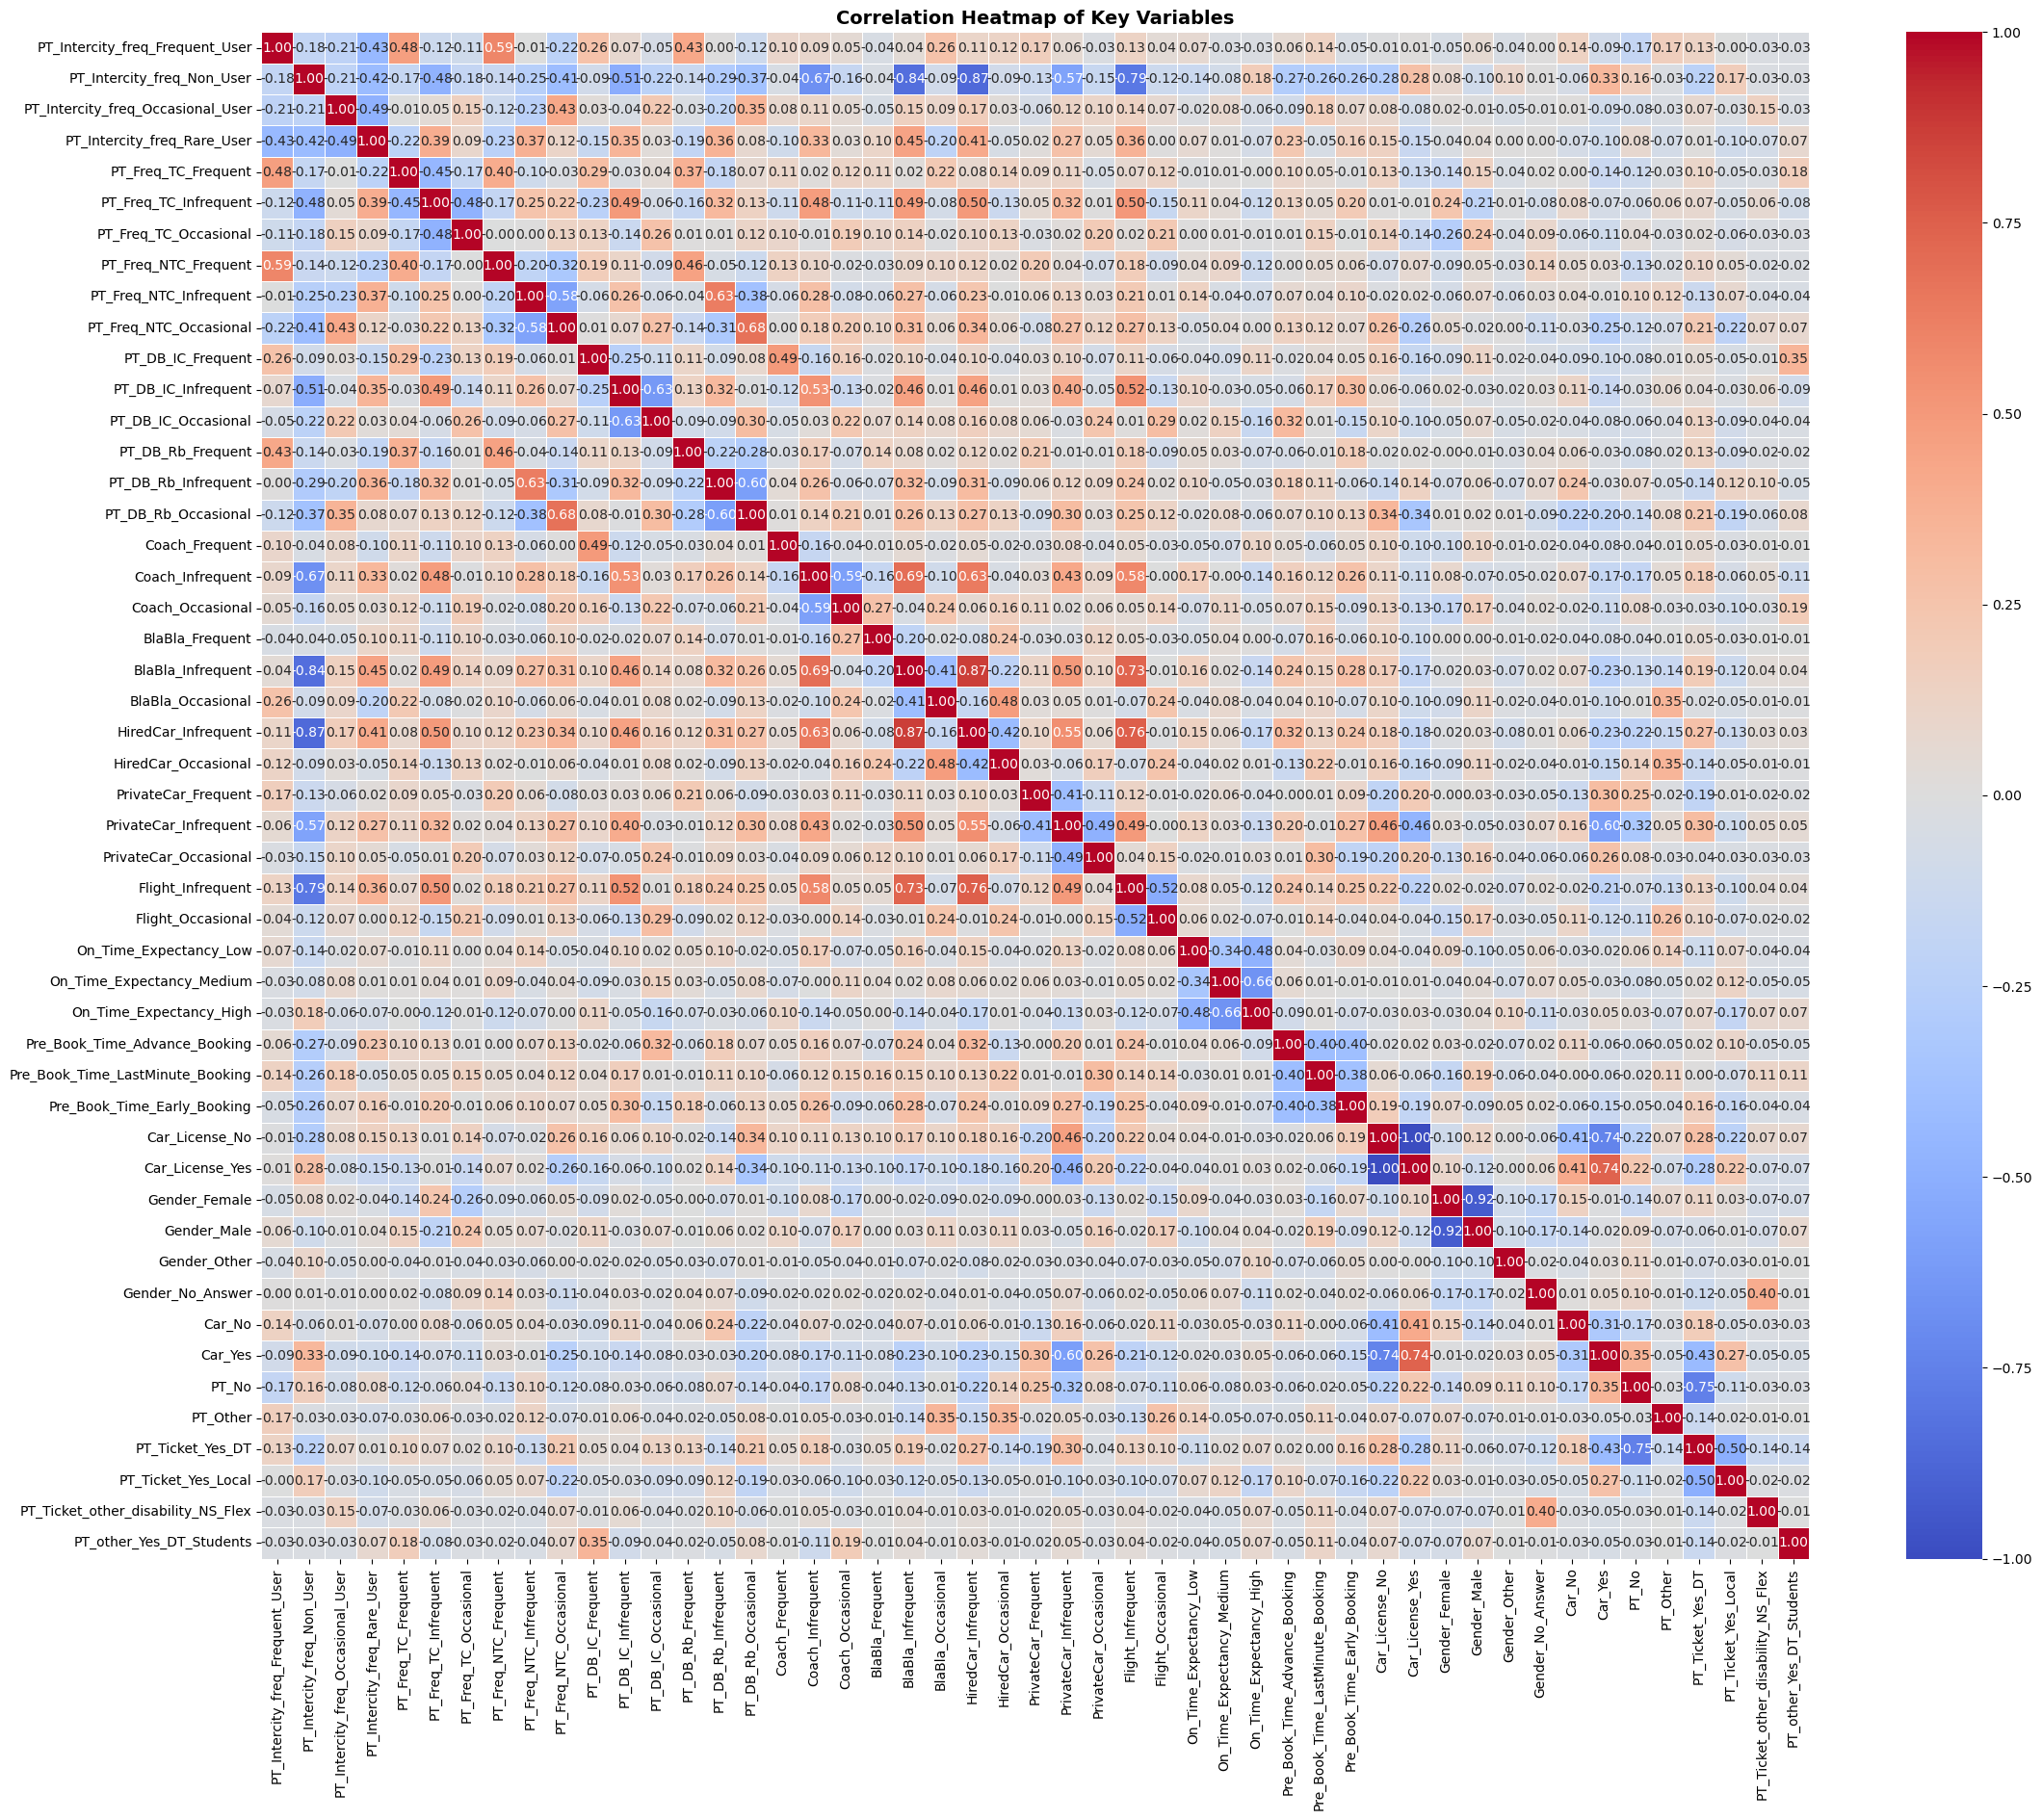

Saved diagnostics:
1. Correlation_Heatmap.png
2. Condition_Index_Plot.png
3. VIF_Results.csv


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from numpy.linalg import svd
from scipy.linalg import svd as svd_robust
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select numeric columns used in your model
vars_for_check = [
       'PT_Intercity_freq_Frequent_User', 'PT_Intercity_freq_Non_User',
       'PT_Intercity_freq_Occasional_User', 'PT_Intercity_freq_Rare_User',
       'PT_Freq_TC_Frequent', 'PT_Freq_TC_Infrequent',
       'PT_Freq_TC_Occasional', 'PT_Freq_NTC_Frequent',
       'PT_Freq_NTC_Infrequent', 'PT_Freq_NTC_Occasional',
       'PT_DB_IC_Frequent', 'PT_DB_IC_Infrequent', 'PT_DB_IC_Occasional',
       'PT_DB_Rb_Frequent', 'PT_DB_Rb_Infrequent', 'PT_DB_Rb_Occasional',
       'Coach_Frequent', 'Coach_Infrequent', 'Coach_Occasional',
       'BlaBla_Frequent', 'BlaBla_Infrequent', 'BlaBla_Occasional',
       'HiredCar_Infrequent', 'HiredCar_Occasional',
       'PrivateCar_Frequent', 'PrivateCar_Infrequent',
       'PrivateCar_Occasional', 'Flight_Infrequent', 'Flight_Occasional',
       'On_Time_Expectancy_Low', 'On_Time_Expectancy_Medium',
       'On_Time_Expectancy_High', 'Pre_Book_Time_Advance_Booking',
       'Pre_Book_Time_LastMinute_Booking', 'Pre_Book_Time_Early_Booking',
       'Car_License_No', 'Car_License_Yes', 'Gender_Female',
       'Gender_Male', 'Gender_Other', 'Gender_No_Answer', 'Car_No',
       'Car_Yes', 'PT_No', 'PT_Other', 'PT_Ticket_Yes_DT',
       'PT_Ticket_Yes_Local', 'PT_Ticket_other_disability_NS_Flex',
       'PT_other_Yes_DT_Students'
]

df_check = df[vars_for_check].select_dtypes(include=[np.number]).dropna()

# Drop constant columns
df_check = df_check.loc[:, df_check.nunique() > 1]

# --- Correlation Heatmap ---
plt.figure(figsize=(23, 19))
corr_matrix = df_check.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Key Variables", fontsize=14, fontweight='bold')
plt.tight_layout()

# Show in notebook
plt.show()

# Save figure
plt.savefig('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/Correlation_HeatmapSD&Freq.png', dpi=300)
plt.close()

# --- Variance Inflation Factor (VIF) ---
vif_data = pd.DataFrame({
    "Variable": df_check.columns,
    "VIF": [variance_inflation_factor(df_check.values, i)
            for i in range(df_check.shape[1])]
})
vif_data.to_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/VIF_ResultsSDFreq.csv', index=False)

# --- Condition Index Visualization ---
# Standardize safely
X = (df_check - df_check.mean()) / df_check.std()
X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="any")

try:
    _, s, _ = svd_robust(X, full_matrices=False, lapack_driver='gesvd')
    condition_index = s[0] / s
    cond_df = pd.DataFrame({
        "Variable_Index": range(1, len(condition_index) + 1),
        "Condition_Index": condition_index
    })


#    plt.figure(figsize=(10, 6))
#    sns.lineplot(x="Variable_Index", y="Condition_Index", data=cond_df, marker="o")
#    plt.axhline(y=30, color='r', linestyle='--', label='Severe Multicollinearity Threshold')
#    plt.title("Condition Index Plot", fontsize=14, fontweight='bold')
#    plt.xlabel("Variable Index")
#    plt.ylabel("Condition Index Value")
#    plt.legend()
#    plt.tight_layout()
#    plt.show()
#    plt.savefig('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/Condition_Index_Plot.png', dpi=300)
#    plt.close()


except np.linalg.LinAlgError:
    print(" SVD did not converge. One or more variables may be perfectly collinear or constant.")
    print("Try checking correlation matrix or dummy variables for perfect linear dependency.")

print("Saved diagnostics:")
print("1. Correlation_Heatmap.png")
print("2. Condition_Index_Plot.png")
print("3. VIF_Results.csv")

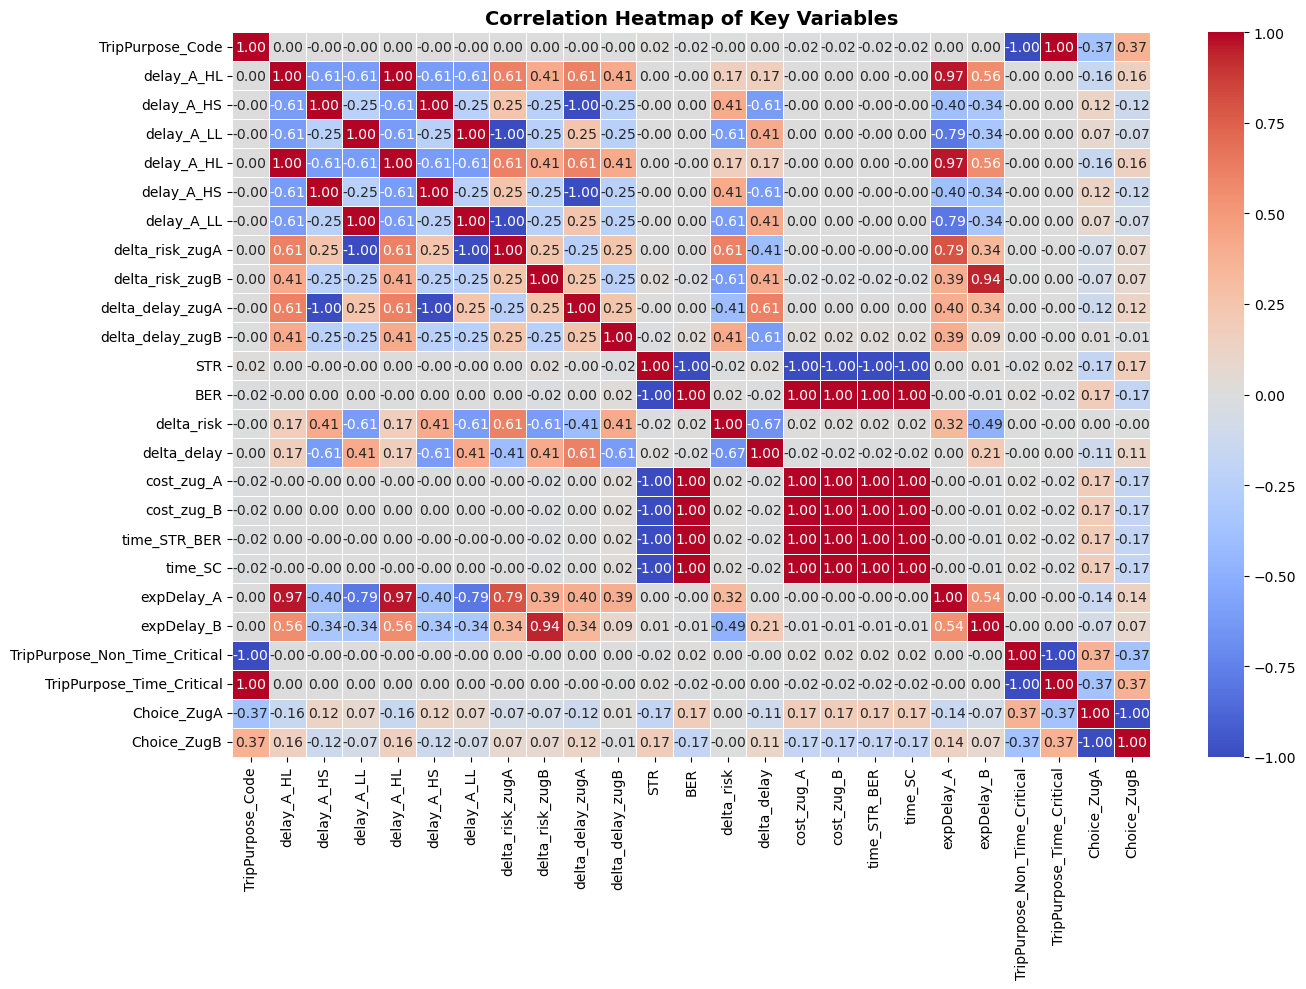

Saved diagnostics:
1. Correlation_Heatmap.png
2. Condition_Index_Plot.png
3. VIF_Results.csv


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from numpy.linalg import svd
from scipy.linalg import svd as svd_robust
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select numeric columns used in your model
vars_for_check = [
       'TripPurpose_Code',
       'delay_A_HL', 'delay_A_HS', 'delay_A_LL', 'delay_A_HL', 'delay_A_HS', 'delay_A_LL',
       'delta_risk_zugA', 'delta_risk_zugB', 'delta_delay_zugA', 'delta_delay_zugB', 'STR',
       'BER', 'delta_risk', 'delta_delay', 'cost_zug_A', 'cost_zug_B',
       #'time_STR', 'time_BER', 
       'time_STR_BER', 'time_SC', 'expDelay_A', 'expDelay_B',
       'TripPurpose_Non_Time_Critical', 'TripPurpose_Time_Critical',
       'Choice_ZugA', 'Choice_ZugB'
]

df_check = df[vars_for_check].select_dtypes(include=[np.number]).dropna()

# Drop constant columns
df_check = df_check.loc[:, df_check.nunique() > 1]

# --- Correlation Heatmap ---
plt.figure(figsize=(14, 10))
corr_matrix = df_check.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Key Variables", fontsize=14, fontweight='bold')
plt.tight_layout()

# Show in notebook
plt.show()

# Save figure
plt.savefig('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/Correlation_Heatmap.png', dpi=300)
plt.close()

# --- Variance Inflation Factor (VIF) ---
vif_data = pd.DataFrame({
    "Variable": df_check.columns,
    "VIF": [variance_inflation_factor(df_check.values, i)
            for i in range(df_check.shape[1])]
})
vif_data.to_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/VIF_Results.csv', index=False)

# --- Condition Index Visualization ---
# Standardize safely
X = (df_check - df_check.mean()) / df_check.std()
X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="any")

try:
    _, s, _ = svd_robust(X, full_matrices=False, lapack_driver='gesvd')
    condition_index = s[0] / s
    cond_df = pd.DataFrame({
        "Variable_Index": range(1, len(condition_index) + 1),
        "Condition_Index": condition_index
    })


#    plt.figure(figsize=(10, 6))
#    sns.lineplot(x="Variable_Index", y="Condition_Index", data=cond_df, marker="o")
#    plt.axhline(y=30, color='r', linestyle='--', label='Severe Multicollinearity Threshold')
#    plt.title("Condition Index Plot", fontsize=14, fontweight='bold')
#    plt.xlabel("Variable Index")
#    plt.ylabel("Condition Index Value")
#    plt.legend()
#    plt.tight_layout()
#    plt.show()
#    plt.savefig('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/Condition_Index_Plot.png', dpi=300)
#    plt.close()


except np.linalg.LinAlgError:
    print(" SVD did not converge. One or more variables may be perfectly collinear or constant.")
    print("Try checking correlation matrix or dummy variables for perfect linear dependency.")

print("Saved diagnostics:")
print("1. Correlation_Heatmap.png")
print("2. Condition_Index_Plot.png")
print("3. VIF_Results.csv")

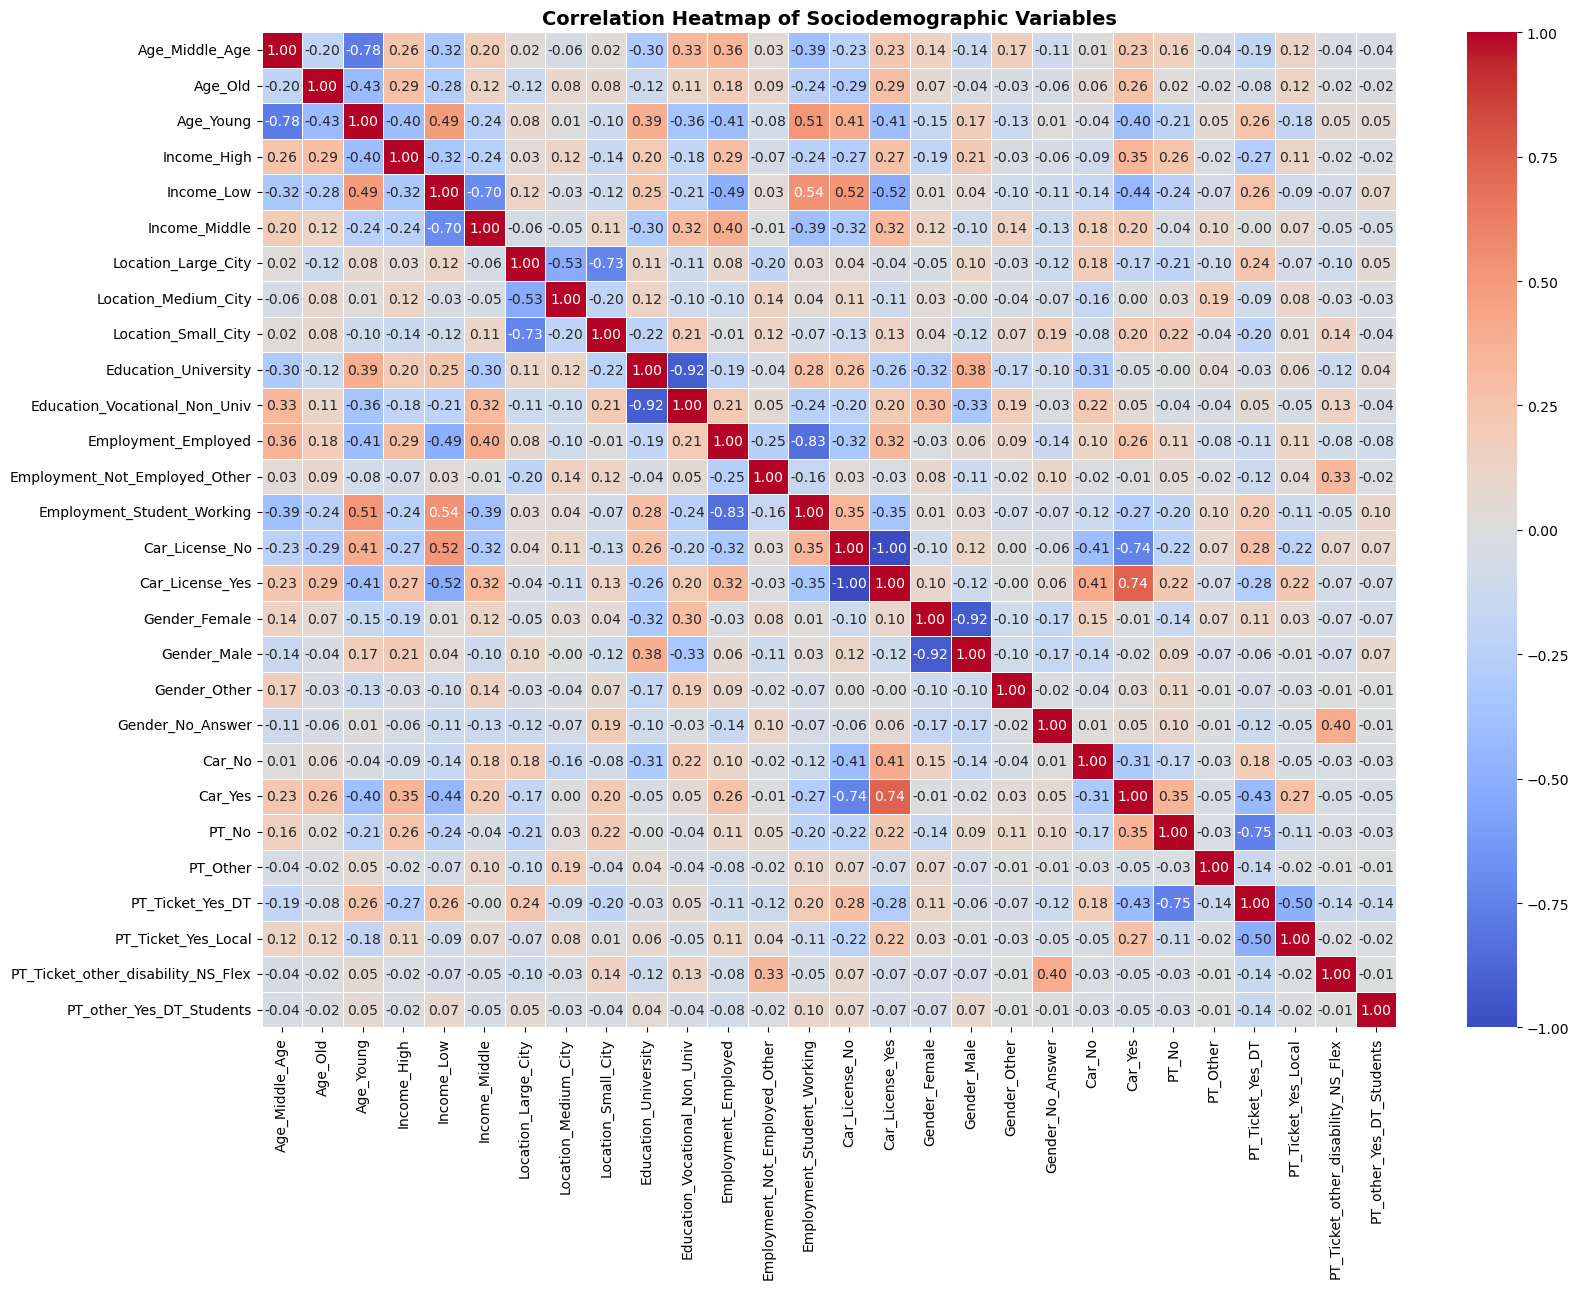

Saved diagnostics:
1. Correlation_HeatmapSD.png
2. Condition_Index_PlotSD.png
3. VIF_ResultsSD.csv


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from numpy.linalg import svd
from scipy.linalg import svd as svd_robust
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select numeric columns used in your model
vars_for_checkSD = [
    'Age_Middle_Age', 'Age_Old',
       'Age_Young', 'Income_High', 'Income_Low', 'Income_Middle',
       'Location_Large_City', 'Location_Medium_City',
       'Location_Small_City', 'Education_University',
       'Education_Vocational_Non_Univ', 'Employment_Employed',
       'Employment_Not_Employed_Other', 'Employment_Student_Working',
       #'PT_Intercity_freq_Frequent_User', 'PT_Intercity_freq_Non_User',
       #'PT_Intercity_freq_Occasional_User', 'PT_Intercity_freq_Rare_User',
       #'PT_Freq_TC_Frequent', 'PT_Freq_TC_Infrequent',
       #'PT_Freq_TC_Occasional', 'PT_Freq_NTC_Frequent',
       #'PT_Freq_NTC_Infrequent', 'PT_Freq_NTC_Occasional',
       #'PT_DB_IC_Frequent', 'PT_DB_IC_Infrequent', 'PT_DB_IC_Occasional',
       #'PT_DB_Rb_Frequent', 'PT_DB_Rb_Infrequent', 'PT_DB_Rb_Occasional',
       #'Coach_Frequent', 'Coach_Infrequent', 'Coach_Occasional',
       #'BlaBla_Frequent', 'BlaBla_Infrequent', 'BlaBla_Occasional',
       #'HiredCar_Infrequent', 'HiredCar_Occasional',
       #'PrivateCar_Frequent', 'PrivateCar_Infrequent',
       #'PrivateCar_Occasional', 'Flight_Infrequent', 'Flight_Occasional',
       #'On_Time_Expectancy_Low', 'On_Time_Expectancy_Medium',
       #'On_Time_Expectancy_High', 'Pre_Book_Time_Advance_Booking',
       #'Pre_Book_Time_LastMinute_Booking', 'Pre_Book_Time_Early_Booking',
       'Car_License_No', 'Car_License_Yes', 'Gender_Female',
       'Gender_Male', 'Gender_Other', 'Gender_No_Answer', 'Car_No',
       'Car_Yes', 'PT_No', 'PT_Other', 'PT_Ticket_Yes_DT',
       'PT_Ticket_Yes_Local', 'PT_Ticket_other_disability_NS_Flex',
       'PT_other_Yes_DT_Students'
]

df_checkSD = df[vars_for_checkSD].select_dtypes(include=[np.number]).dropna()

# Drop constant columns
df_checkSD = df_checkSD.loc[:, df_checkSD.nunique() > 1]

# --- Correlation Heatmap ---
plt.figure(figsize=(17, 13))
corr_matrixSD = df_checkSD.corr()
sns.heatmap(corr_matrixSD, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Sociodemographic Variables", fontsize=14, fontweight='bold')
plt.tight_layout()

# Show in notebook
plt.show()

# Save figure
plt.savefig('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/Correlation_HeatmapSD.png', dpi=300)
plt.close()

# --- Variance Inflation Factor (VIF) ---
vif_dataSD = pd.DataFrame({
    "Variable": df_checkSD.columns,
    "VIF": [variance_inflation_factor(df_checkSD.values, i)
            for i in range(df_checkSD.shape[1])]
})
vif_dataSD.to_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/VIF_Results.csv', index=False)

# --- Condition Index Visualization ---
# Standardize safely
X = (df_checkSD - df_checkSD.mean()) / df_checkSD.std()
X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="any")

try:
    _, s, _ = svd_robust(X, full_matrices=False, lapack_driver='gesvd')
    condition_index = s[0] / s
    cond_df = pd.DataFrame({
        "Variable_Index": range(1, len(condition_index) + 1),
        "Condition_Index": condition_index
    })


#    plt.figure(figsize=(10, 6))
#    sns.lineplot(x="Variable_Index", y="Condition_Index", data=cond_df, marker="o")
#    plt.axhline(y=30, color='r', linestyle='--', label='Severe Multicollinearity Threshold')
#    plt.title("Condition Index Plot", fontsize=14, fontweight='bold')
#    plt.xlabel("Variable Index")
#    plt.ylabel("Condition Index Value")
#    plt.legend()
#    plt.tight_layout()
#    plt.show()
#    plt.savefig('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/Condition_Index_Plot.png', dpi=300)
#    plt.close()


except np.linalg.LinAlgError:
    print(" SVD did not converge. One or more variables may be perfectly collinear or constant.")
    print("Try checking correlation matrix or dummy variables for perfect linear dependency.")

print("Saved diagnostics:")
print("1. Correlation_HeatmapSD.png")
print("2. Condition_Index_PlotSD.png")
print("3. VIF_ResultsSD.csv")

In [47]:
# --- Detect and Remove Collinear Variables (Detailed + Editable Version) ---

import numpy as np
import pandas as pd

# --- Step 1: Compute correlation matrix ---
corr_matrix = df_check.corr().abs()

# --- Step 2: Define threshold ---
corr_threshold = 0.9  # You can adjust this (e.g., 0.85, 0.95)

# --- Step 3: Identify pairs with high correlation ---
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Collect all variable pairs above threshold with their correlation values
high_corr_pairs = (
    upper_tri.stack()
    .reset_index()
    .rename(columns={"level_0": "Variable_1", "level_1": "Variable_2", 0: "Correlation"})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs["Correlation"] > corr_threshold]

# Display all highly correlated pairs
print(" Highly correlated variable pairs (|r| >", corr_threshold, "):")
print(high_corr_pairs.sort_values(by="Correlation", ascending=False).to_string(index=False))

# --- Step 4: Identify individual variables with high collinearity ---
max_corr_values = upper_tri.max(axis=0)
collinear_vars = max_corr_values[max_corr_values > corr_threshold]

print("\n Variables showing collinearity above threshold:")
for var, val in collinear_vars.items():
    print(f"{var:35s}  max |r| = {val:.3f}")

# --- Step 5: Create explicit drop list (you can manually edit this) ---
to_drop = list(collinear_vars.index)

# MANUALLY EDIT THIS LIST BELOW if you want to keep some variables
# For example, to keep 'cost_zug_A', delete it from this list.
to_drop = [
    'TripPurpose_Non_Time_Critical',
    'TripPurpose_Time_Critical',
    'Car_License_No',
    '',
    # example entries (the real ones will be printed above, copy them here):
    # 'Age_Old',
    # 'Income_High',
    # 'Car_License_Yes',
] + to_drop  # keep automatically detected ones, editable by you

print("\n Variables marked for removal:")
print(to_drop)

# --- Step 6: Drop collinear variables safely ---
df_reduced = df_check.drop(columns=to_drop, errors="ignore")

# --- Step 7: Clean NaNs and infinities ---
df_reduced = df_reduced.replace([np.inf, -np.inf], np.nan)

# Report NaNs before cleanup
nan_summary = df_reduced.isnull().sum()
if nan_summary.sum() > 0:
    print("\nNaN count per variable before cleanup:")
    print(nan_summary[nan_summary > 0])

# Drop rows with too many NaNs (>=30% missing values)
nan_fraction = df_reduced.isna().mean(axis=1)
df_reduced = df_reduced.loc[nan_fraction < 0.3, :].dropna(axis=0, how="all")

# --- Step 8: Final summary ---
print("\n Final reduced DataFrame shape:", df_reduced.shape)
print("Remaining variables after collinearity removal:")
print(df_reduced.columns.tolist())

# --- Step 9: Save cleaned dataset ---
output_path = '/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/Cleaned_Dataset_NoCollinearity.csv'
df_reduced.to_csv(output_path, index=False)
print(f"\n Saved cleaned dataset as '{output_path}'")

 Highly correlated variable pairs (|r| > 0.9 ):
                   Variable_1                    Variable_2  Correlation
                   delay_A_HS              delta_delay_zugA     1.000000
                   delay_A_HS              delta_delay_zugA     1.000000
                  Choice_ZugA                   Choice_ZugB     1.000000
                   delay_A_LL               delta_risk_zugA     1.000000
                          STR                  time_STR_BER     1.000000
                   delay_A_LL               delta_risk_zugA     1.000000
TripPurpose_Non_Time_Critical     TripPurpose_Time_Critical     1.000000
                   cost_zug_B                  time_STR_BER     1.000000
                   cost_zug_A                       time_SC     1.000000
             TripPurpose_Code     TripPurpose_Time_Critical     1.000000
             TripPurpose_Code TripPurpose_Non_Time_Critical     1.000000
                   delay_A_HL                    delay_A_HL     1.000000
   

In [48]:
df['choice_numeric'] = df['Choice_ZugA'].map({1: 1, 0: 2})

Choice = Variable('choice_numeric')

In [49]:
from biogeme.expressions import Beta, Variable

# Alternative Specific Constants (ASCs)
ASC_ZUGA = Beta('ASC_ZUGA', 0, None, None, 1)
ASC_ZUGB = Beta('ASC_ZUGB', 0, None, None, 0)

# Core Attributes
B_COST = Beta('B_COST', 0, None, None, 0)
B_TIME = Beta('B_TIME', 0, None, None, 0)

# Reliability parameters separated by delay type (duration and risk)
#B_RELIABILITY = Beta('B_RELIABILITY', 0, None, None, 0)
#B_DELAY_LS = Beta('B_DELAY_LS', 0, None, None, 0)
B_DELAY_LL = Beta('B_DELAY_LL', 0, None, None, 0)
B_DELAY_HS = Beta('B_DELAY_HS', 0, None, None, 0)
B_DELAY_HL = Beta('B_DELAY_HL', 0, None, None, 0)

# (Optional) route-specific constants if you want route/time effects
ASC_B_STR = Beta('ASC_B_STR', 0, None, None, 0)
ASC_B_BER = Beta('ASC_B_BER', 0, None, None, 0)

B_DELAY_A = Beta('B_DELAY_A', 0, None, None, 0) 
B_DELAY_B = Beta('B_DELAY_B', 0, None, None, 0) 

#Delta Delay and Risk presented separately
B_DELAY = Beta('B_DELAY', 0, None, None, 0)
B_RISK = Beta('B_RISK', 0, None, None, 0)

B_INTERACTION = Beta('B_INTERACTION', 0, None, None, 0)

# Socio-demographic constants (Beta terms)
B_AGE_OLD = Beta('B_AGE_OLD', 0, None, None, 0)
B_AGE_YOUNG = Beta('B_AGE_YOUNG', 0, None, None, 0)

B_INCOME_HIGH = Beta('B_INCOME_HIGH', 0, None, None, 0)
B_INCOME_LOW = Beta('B_INCOME_LOW', 0, None, None, 0)

B_LOCATION_LARGE_CITY = Beta('B_LOCATION_LARGE_CITY', 0, None, None, 0)
B_LOCATION_MEDIUM_CITY = Beta('B_LOCATION_MEDIUM_CITY', 0, None, None, 0)

B_EDUCATION_UNIVERSITY = Beta('B_EDUCATION_UNIVERSITY', 0, None, None, 0)

B_EMPLOYED = Beta('B_EMPLOYED', 0, None, None, 0)
B_NOT_EMPLOYED_OTHER = Beta('B_NOT_EMPLOYED_OTHER', 0, None, None, 0)

B_CAR_LICENSE_NO = Beta('B_CAR_LICENSE_NO', 0, None, None, 0)
B_CAR_LICENSE_YES = Beta('B_CAR_LICENSE_YES', 0, None, None, 0)

B_GENDER_FEMALE = Beta('B_GENDER_FEMALE', 0, None, None, 0)
B_GENDER_MALE = Beta('B_GENDER_MALE', 0, None, None, 0)
B_GENDER_OTHER = Beta('B_GENDER_OTHER', 0, None, None, 0)
B_GENDER_NO_ANSWER = Beta('B_GENDER_NO_ANSWER', 0, None, None, 0)

B_CAR_NO = Beta('B_CAR_NO', 0, None, None, 0)

B_PT_OTHER = Beta('B_PT_OTHER', 0, None, None, 0)
B_PT_TICKET_YES_DT = Beta('B_PT_TICKET_YES_DT', 0, None, None, 0)
B_PT_TICKET_YES_LOCAL = Beta('B_PT_TICKET_YES_LOCAL', 0, None, None, 0)
B_PT_TICKET_OTHER_DISABILITY_NS_FLEX = Beta('B_PT_TICKET_OTHER_DISABILITY_NS_FLEX', 0, None, None, 0)
B_PT_OTHER_YES_DT_STUDENTS = Beta('B_PT_OTHER_YES_DT_STUDENTS', 0, None, None, 0)

B_TRIP_PURPOSE_NON_TIME_CRITICAL = Beta('B_TRIP_PURPOSE_NON_TIME_CRITICAL', 0, None, None, 0)

B_PT_Intercity_freq_Frequent_User = Beta('B_PT_Intercity_freq_Frequent_User', 0, None, None, 0)
B_PT_Intercity_freq_Non_User = Beta('B_PT_Intercity_freq_Non_User', 0, None, None, 0)
B_PT_Intercity_freq_Occasional_User = Beta('B_PT_Intercity_freq_Occasional_User', 0, None, None, 0)

B_PT_Freq_TC_Frequent = Beta('B_PT_Freq_TC_Frequent', 0, None, None, 0)
B_PT_Freq_TC_Infrequent = Beta('B_PT_Freq_TC_Infrequent', 0, None, None, 0)

B_PT_Freq_NTC_Frequent = Beta('B_PT_Freq_NTC_Frequent', 0, None, None, 0)
B_PT_Freq_NTC_Infrequent = Beta('B_PT_Freq_NTC_Infrequent', 0, None, None, 0)

B_PT_DB_IC_Frequent = Beta('B_PT_DB_IC_Frequent', 0, None, None, 0)
B_PT_DB_IC_Infrequent = Beta('B_PT_DB_IC_Infrequent', 0, None, None, 0)

B_PT_DB_Rb_Frequent = Beta('B_PT_DB_Rb_Frequent', 0, None, None, 0)
B_PT_DB_Rb_Infrequent = Beta('B_PT_DB_Rb_Infrequent', 0, None, None, 0)

B_Coach_Frequent = Beta('B_Coach_Frequent', 0, None, None, 0)
B_Coach_Infrequent = Beta('B_Coach_Infrequent', 0, None, None, 0)

B_BlaBla_Frequent = Beta('B_BlaBla_Frequent', 0, None, None, 0)
B_BlaBla_Infrequent = Beta('B_BlaBla_Infrequent', 0, None, None, 0)

B_HiredCar_Infrequent = Beta('B_HiredCar_Infrequent', 0, None, None, 0)

B_PrivateCar_Frequent = Beta('B_PrivateCar_Frequent', 0, None, None, 0)
B_PrivateCar_Infrequent = Beta('B_PrivateCar_Infrequent', 0, None, None, 0)

B_Flight_Infrequent = Beta('B_Flight_Infrequent', 0, None, None, 0)

B_On_Time_Expectancy_Low = Beta('B_On_Time_Expectancy_Low', 0, None, None, 0)

B_On_Time_Expectancy_High = Beta('B_On_Time_Expectancy_High', 0, None, None, 0)

B_Pre_Book_Time_LastMinute_Booking = Beta('B_Pre_Book_Time_LastMinute_Booking', 0, None, None, 0)
B_Pre_Book_Time_Early_Booking = Beta('B_Pre_Book_Time_Early_Booking', 0, None, None, 0)


In [50]:
from biogeme.expressions import Beta, Variable

# -----------------------
# Alternative-specific constants
# -----------------------
ASC_ZUGA = Beta('ASC_ZUGA', 0, None, None, 1)  # normalize A's ASC to 0
ASC_ZUGB = Beta('ASC_ZUGB', 0, None, None, 0)

# Core attributes (alt-specific versions)
# -----------------------
# COST: alt-specific and identified → both free
B_COST_A = Beta('B_COST_A', 0, None, None, 0)
B_COST_B = Beta('B_COST_B', 0, None, None, 0)

# TIME: if identical across alts (set-level), FIX A-side to 0 and estimate B-side
# If truly different by alt, set both free (and ensure columns differ).
B_TIME_A = Beta('B_TIME_A', 0, None, None, 0)  # fix to 0 to avoid set-level cancellation
B_TIME_B = Beta('B_TIME_B', 0, None, None, 0)

# -----------------------
# Reliability dummies (per alternative; LS is the base)
# -----------------------
B_DELAY_HL_A = Beta('B_DELAY_HL_A', 0, None, None, 0)
B_DELAY_HS_A = Beta('B_DELAY_HS_A', 0, None, None, 0)
B_DELAY_LL_A = Beta('B_DELAY_LL_A', 0, None, None, 0)

B_DELAY_HL_B = Beta('B_DELAY_HL_B', 0, None, None, 0)
B_DELAY_HS_B = Beta('B_DELAY_HS_B', 0, None, None, 0)
B_DELAY_LL_B = Beta('B_DELAY_LL_B', 0, None, None, 0)

B_RISK_A = Beta('B_RISK_A', 0, None, None, 0)
B_RISK_B = Beta('B_RISK_B', 0, None, None, 0)

B_INTERACTION_A = Beta('B_INTERACTION_A', 0, None, None, 0) 
B_INTERACTION_B = Beta('B_INTERACTION_B', 0, None, None, 0) 

# ----------------------------------------------------------
# A/B-SPECIFIC COEFFICIENTS (A fixed to 0, B estimated free)
# ----------------------------------------------------------
# (Add any others you still keep; ensure one base per family is omitted in the data)

B_AGE_OLD_A    = Beta('B_AGE_OLD_A',    0, None, None, 0)  # fixed 0
B_AGE_OLD_B    = Beta('B_AGE_OLD_B',    0, None, None, 0)

B_AGE_YOUNG_A  = Beta('B_AGE_YOUNG_A',  0, None, None, 0)
B_AGE_YOUNG_B  = Beta('B_AGE_YOUNG_B',  0, None, None, 0)

B_INCOME_HIGH_A = Beta('B_INCOME_HIGH_A', 0, None, None, 0)
B_INCOME_HIGH_B = Beta('B_INCOME_HIGH_B', 0, None, None, 0)

B_INCOME_LOW_A  = Beta('B_INCOME_LOW_A',  0, None, None, 0)
B_INCOME_LOW_B  = Beta('B_INCOME_LOW_B',  0, None, None, 0)

B_GENDER_FEMALE_A = Beta('B_GENDER_FEMALE_A', 0, None, None, 0)
B_GENDER_FEMALE_B = Beta('B_GENDER_FEMALE_B', 0, None, None, 0)

B_GENDER_MALE_A = Beta('B_GENDER_MALE_A', 0, None, None, 0)
B_GENDER_MALE_B = Beta('B_GENDER_MALE_B', 0, None, None, 0)

B_LOCATION_LARGE_CITY_A              = Beta('B_LOCATION_LARGE_CITY_A',              0, None, None, 0)
B_LOCATION_LARGE_CITY_B              = Beta('B_LOCATION_LARGE_CITY_B',              0, None, None, 0)

B_LOCATION_MEDIUM_CITY_A             = Beta('B_LOCATION_MEDIUM_CITY_A',             0, None, None, 0)
B_LOCATION_MEDIUM_CITY_B             = Beta('B_LOCATION_MEDIUM_CITY_B',             0, None, None, 0)

B_EDUCATION_UNIVERSITY_A             = Beta('B_EDUCATION_UNIVERSITY_A',             0, None, None, 0)
B_EDUCATION_UNIVERSITY_B             = Beta('B_EDUCATION_UNIVERSITY_B',             0, None, None, 0)

B_EMPLOYED_A                         = Beta('B_EMPLOYED_A',                         0, None, None, 0)
B_EMPLOYED_B                         = Beta('B_EMPLOYED_B',                         0, None, None, 0)

B_CAR_LICENSE_YES_A                  = Beta('B_CAR_LICENSE_YES_A',                  0, None, None, 0)
B_CAR_LICENSE_YES_B                  = Beta('B_CAR_LICENSE_YES_B',                  0, None, None, 0)

B_CAR_YES_A                          = Beta('B_CAR_YES_A',                          0, None, None, 0)
B_CAR_YES_B                          = Beta('B_CAR_YES_B',                          0, None, None, 0)

B_PT_TICKET_YES_DT_A                 = Beta('B_PT_TICKET_YES_DT_A',                 0, None, None, 0)
B_PT_TICKET_YES_DT_B                 = Beta('B_PT_TICKET_YES_DT_B',                 0, None, None, 0)

B_TRIP_PURPOSE_NON_TIME_CRITICAL_A   = Beta('B_TRIP_PURPOSE_NON_TIME_CRITICAL_A',   0, None, None, 0)
B_TRIP_PURPOSE_NON_TIME_CRITICAL_B   = Beta('B_TRIP_PURPOSE_NON_TIME_CRITICAL_B',   0, None, None, 0)

B_PT_Intercity_freq_Frequent_User_A  = Beta('B_PT_Intercity_freq_Frequent_User_A',  0, None, None, 0)
B_PT_Intercity_freq_Frequent_User_B  = Beta('B_PT_Intercity_freq_Frequent_User_B',  0, None, None, 0)

B_Coach_Frequent_A                   = Beta('B_Coach_Frequent_A',                   0, None, None, 0)
B_Coach_Frequent_B                   = Beta('B_Coach_Frequent_B',                   0, None, None, 0)

B_PrivateCar_Frequent_A              = Beta('B_PrivateCar_Frequent_A',              0, None, None, 0)
B_PrivateCar_Frequent_B              = Beta('B_PrivateCar_Frequent_B',              0, None, None, 0)

B_Flight_Infrequent_A                = Beta('B_Flight_Infrequent_A',                0, None, None, 0)
B_Flight_Infrequent_B                = Beta('B_Flight_Infrequent_B',                0, None, None, 0)

B_On_Time_Expectancy_High_A          = Beta('B_On_Time_Expectancy_High_A',          0, None, None, 0)
B_On_Time_Expectancy_High_B          = Beta('B_On_Time_Expectancy_High_B',          0, None, None, 0)

B_Pre_Book_Time_Early_Booking_A      = Beta('B_Pre_Book_Time_Early_Booking_A',      0, None, None, 0)
B_Pre_Book_Time_Early_Booking_B      = Beta('B_Pre_Book_Time_Early_Booking_B',      0, None, None, 0)

In [51]:
from biogeme.expressions import Beta, Variable

# Utility function for Train A
V_A0 = (
    ASC_ZUGA
    + B_COST * cost_zug_A
    + B_DELAY_HL * delay_A_HL
    + B_DELAY_HS * delay_A_HS
    + B_DELAY_LL * delay_A_LL
     # Sociodemographic effects for Train B
    + B_AGE_OLD * Age_Old
    + B_AGE_YOUNG * Age_Young

    + B_INCOME_HIGH * Income_High
    + B_INCOME_LOW * Income_Low

    + B_LOCATION_LARGE_CITY * Location_Large_City
    + B_LOCATION_MEDIUM_CITY * Location_Medium_City

    + B_EDUCATION_UNIVERSITY * Education_University

    + B_EMPLOYED * Employment_Employed
#    + B_NOT_EMPLOYED_OTHER * Employment_Not_Employed_Other

#    + B_CAR_LICENSE_NO * Car_License_No
    + B_CAR_LICENSE_YES * Car_License_Yes

    + B_GENDER_FEMALE * Gender_Female
#    + B_GENDER_MALE * Gender_Male
#    + B_GENDER_OTHER * Gender_Other
#    + B_GENDER_NO_ANSWER * Gender_No_Answer

    + B_CAR_NO * Car_No

#    + B_PT_OTHER * PT_Other
    + B_PT_TICKET_YES_DT * PT_Ticket_Yes_DT
#    + B_PT_TICKET_YES_LOCAL * PT_Ticket_Yes_Local
#    + B_PT_TICKET_OTHER_DISABILITY_NS_FLEX * PT_Ticket_other_disability_NS_Flex
#    + B_PT_OTHER_YES_DT_STUDENTS * PT_other_Yes_DT_Students

    + B_TRIP_PURPOSE_NON_TIME_CRITICAL * TripPurpose_Non_Time_Critical
    # Added PT frequency, booking, and other new variables
    + B_PT_Intercity_freq_Frequent_User * PT_Intercity_freq_Frequent_User
#    + B_PT_Intercity_freq_Non_User * PT_Intercity_freq_Non_User
#    + B_PT_Intercity_freq_Occasional_User * PT_Intercity_freq_Occasional_User

#    + B_PT_Freq_TC_Frequent * PT_Freq_TC_Frequent
#    + B_PT_Freq_TC_Infrequent * PT_Freq_TC_Infrequent

#    + B_PT_Freq_NTC_Frequent * PT_Freq_NTC_Frequent
#    + B_PT_Freq_NTC_Infrequent * PT_Freq_NTC_Infrequent

#    + B_PT_DB_IC_Frequent * PT_DB_IC_Frequent
#    + B_PT_DB_IC_Infrequent * PT_DB_IC_Infrequent

#    + B_PT_DB_Rb_Frequent * PT_DB_Rb_Frequent
#    + B_PT_DB_Rb_Infrequent * PT_DB_Rb_Infrequent

    + B_Coach_Frequent * Coach_Frequent
#    + B_Coach_Infrequent * Coach_Infrequent

#    + B_BlaBla_Frequent * BlaBla_Frequent
#    + B_BlaBla_Infrequent * BlaBla_Infrequent

#    + B_HiredCar_Infrequent * HiredCar_Infrequent

    + B_PrivateCar_Frequent * PrivateCar_Frequent
#    + B_PrivateCar_Infrequent * PrivateCar_Infrequent

    + B_Flight_Infrequent * Flight_Infrequent

#    + B_On_Time_Expectancy_Low * On_Time_Expectancy_Low
    + B_On_Time_Expectancy_High * On_Time_Expectancy_High

#    + B_Pre_Book_Time_LastMinute_Booking * Pre_Book_Time_LastMinute_Booking
    + B_Pre_Book_Time_Early_Booking * Pre_Book_Time_Early_Booking

)

#  + B_GENDER_OTHER * Gender_Other
  #  + B_GENDER_NO_ANSWER * Gender_No_Answer

#  + B_PT_OTHER * PT_Other
#  + B_PT_TICKET_OTHER_DISABILITY_NS_FLEX * PT_Ticket_other_disability_NS_Flex
  #  + B_PT_OTHER_YES_DT_STUDENTS * PT_other_Yes_DT_Students
 
 #   + B_HiredCar_Infrequent * HiredCar_Infrequent 
 #  + B_Flight_Infrequent * Flight_Infrequent
# Utility function for Train B
V_B0 = (
    ASC_ZUGB
    + ASC_B_STR * STR
    + B_COST * cost_zug_B
    + B_DELAY_HL * delay_B_HL
    + B_DELAY_HS * delay_B_HS
    + B_DELAY_LL * delay_B_LL
    
      # Sociodemographic effects for Train B
    + B_AGE_OLD * Age_Old
    + B_AGE_YOUNG * Age_Young

    + B_INCOME_HIGH * Income_High
    + B_INCOME_LOW * Income_Low

    + B_LOCATION_LARGE_CITY * Location_Large_City
    + B_LOCATION_MEDIUM_CITY * Location_Medium_City

    + B_EDUCATION_UNIVERSITY * Education_University

    + B_EMPLOYED * Employment_Employed
#    + B_NOT_EMPLOYED_OTHER * Employment_Not_Employed_Other

#    + B_CAR_LICENSE_NO * Car_License_No
    + B_CAR_LICENSE_YES * Car_License_Yes

    + B_GENDER_FEMALE * Gender_Female
#    + B_GENDER_MALE * Gender_Male
#    + B_GENDER_OTHER * Gender_Other
#    + B_GENDER_NO_ANSWER * Gender_No_Answer

    + B_CAR_NO * Car_No

#    + B_PT_OTHER * PT_Other
    + B_PT_TICKET_YES_DT * PT_Ticket_Yes_DT
#    + B_PT_TICKET_YES_LOCAL * PT_Ticket_Yes_Local
#    + B_PT_TICKET_OTHER_DISABILITY_NS_FLEX * PT_Ticket_other_disability_NS_Flex
#    + B_PT_OTHER_YES_DT_STUDENTS * PT_other_Yes_DT_Students

    + B_TRIP_PURPOSE_NON_TIME_CRITICAL * TripPurpose_Non_Time_Critical
    # Added PT frequency, booking, and other new variables
    + B_PT_Intercity_freq_Frequent_User * PT_Intercity_freq_Frequent_User
#    + B_PT_Intercity_freq_Non_User * PT_Intercity_freq_Non_User
#    + B_PT_Intercity_freq_Occasional_User * PT_Intercity_freq_Occasional_User

#    + B_PT_Freq_TC_Frequent * PT_Freq_TC_Frequent
#    + B_PT_Freq_TC_Infrequent * PT_Freq_TC_Infrequent

#    + B_PT_Freq_NTC_Frequent * PT_Freq_NTC_Frequent
#    + B_PT_Freq_NTC_Infrequent * PT_Freq_NTC_Infrequent

#    + B_PT_DB_IC_Frequent * PT_DB_IC_Frequent
#    + B_PT_DB_IC_Infrequent * PT_DB_IC_Infrequent

#    + B_PT_DB_Rb_Frequent * PT_DB_Rb_Frequent
#    + B_PT_DB_Rb_Infrequent * PT_DB_Rb_Infrequent

    + B_Coach_Frequent * Coach_Frequent
#    + B_Coach_Infrequent * Coach_Infrequent

#    + B_BlaBla_Frequent * BlaBla_Frequent
#    + B_BlaBla_Infrequent * BlaBla_Infrequent

#    + B_HiredCar_Infrequent * HiredCar_Infrequent

    + B_PrivateCar_Frequent * PrivateCar_Frequent
#    + B_PrivateCar_Infrequent * PrivateCar_Infrequent

    + B_Flight_Infrequent * Flight_Infrequent

#    + B_On_Time_Expectancy_Low * On_Time_Expectancy_Low
    + B_On_Time_Expectancy_High * On_Time_Expectancy_High

#    + B_Pre_Book_Time_LastMinute_Booking * Pre_Book_Time_LastMinute_Booking
    + B_Pre_Book_Time_Early_Booking * Pre_Book_Time_Early_Booking

)


In [52]:
##2 Things: delay_HL is not for Train B so it is omitted from there, besides the error was infinite and the estimate was 0.

#secondly: delay_LS considered as reference, or should we consider a reference which occurs in both trains? 
#since delay_LS isn't in Train A, then how will the model account the reference?


# --- Utilities ---------------------------------------------------------
# (Assumes these Variable(...) exist:
#  cost_zug_A, cost_zug_B, time_zug_A, time_zug_B,
#  delay_A_HL, delay_A_HS, delay_A_LL, delay_B_HL, delay_B_HS, delay_B_LL,
#  Age_Old, Age_Young, Income_High, Income_Low, Gender_Female, Gender_Male,
#  Location_Large_City, Location_Medium_City, Education_University, Employed,
#  Car_License_Yes, Car_Yes, PT_Ticket_Yes_DT, TripPurpose_Non_Time_Critical,
#  PT_Intercity_freq_Frequent_User, Coach_Frequent, PrivateCar_Frequent,
#  Flight_Infrequent, On_Time_Expectancy_High, Pre_Book_Time_Early_Booking)

V_A1 = (
    ASC_ZUGA
    + B_TIME_A * time_SC
    + B_COST_A * cost_zug_A
    # Reliability (A-side; LS is base)
    + B_DELAY_HL_A * delay_A_HL
    + B_DELAY_HS_A * delay_A_HS
    + B_DELAY_LL_A * delay_A_LL
    # Socio/location/etc. (A-side fixed to 0 for identification)
    + B_AGE_OLD_A    * Age_Old
    + B_AGE_YOUNG_A  * Age_Young
    + B_INCOME_HIGH_A * Income_High
    + B_INCOME_LOW_A  * Income_Low
    + B_GENDER_FEMALE_A * Gender_Female
    + B_LOCATION_LARGE_CITY_A  * Location_Large_City
    + B_LOCATION_MEDIUM_CITY_A * Location_Medium_City
    + B_EDUCATION_UNIVERSITY_A * Education_University
    + B_EMPLOYED_A             * Employment_Employed
    + B_CAR_LICENSE_YES_A      * Car_License_Yes
    + B_CAR_YES_A              * Car_Yes
    + B_PT_TICKET_YES_DT_A                 * PT_Ticket_Yes_DT
    + B_TRIP_PURPOSE_NON_TIME_CRITICAL_A   * TripPurpose_Non_Time_Critical
    + B_PT_Intercity_freq_Frequent_User_A  * PT_Intercity_freq_Frequent_User
    + B_Coach_Frequent_A                   * Coach_Frequent
    + B_PrivateCar_Frequent_A              * PrivateCar_Frequent
    + B_Flight_Infrequent_A                * Flight_Infrequent
    + B_On_Time_Expectancy_High_A          * On_Time_Expectancy_High
    + B_Pre_Book_Time_Early_Booking_A      * Pre_Book_Time_Early_Booking
)

V_B1 = (
    ASC_ZUGB
    + B_TIME_B * time_SC
    + B_COST_B * cost_zug_B
    # Reliability (B-side; LS is base)
   # + B_DELAY_HL_B * delay_B_HL
    + B_DELAY_HS_B * delay_B_HS
    + B_DELAY_LL_B * delay_B_LL
    # Socio/location/etc. (B-side estimated; A-side fixed in V_A)
    + B_AGE_OLD_B    * Age_Old
    + B_AGE_YOUNG_B  * Age_Young
    + B_INCOME_HIGH_B * Income_High
    + B_INCOME_LOW_B  * Income_Low
    + B_GENDER_FEMALE_B * Gender_Female
    + B_LOCATION_LARGE_CITY_B  * Location_Large_City
    + B_LOCATION_MEDIUM_CITY_B * Location_Medium_City
    + B_EDUCATION_UNIVERSITY_B * Education_University
    + B_EMPLOYED_B             * Employment_Employed
    + B_CAR_LICENSE_YES_B      * Car_License_Yes
    + B_CAR_YES_B              * Car_Yes
    + B_PT_TICKET_YES_DT_B                 * PT_Ticket_Yes_DT
    + B_TRIP_PURPOSE_NON_TIME_CRITICAL_B   * TripPurpose_Non_Time_Critical
    + B_PT_Intercity_freq_Frequent_User_B  * PT_Intercity_freq_Frequent_User
    + B_Coach_Frequent_B                   * Coach_Frequent
    + B_PrivateCar_Frequent_B              * PrivateCar_Frequent
    + B_Flight_Infrequent_B                * Flight_Infrequent
    + B_On_Time_Expectancy_High_B          * On_Time_Expectancy_High
    + B_Pre_Book_Time_Early_Booking_B      * Pre_Book_Time_Early_Booking
)


In [53]:
############ IMPORTANT
######## use the same model specs., estimate SEPARATELY for STR / BER
######## i.e. filter the results STR / BER

# Utility function for Train A
V_A2 = (
    ASC_ZUGA
    + B_TIME_A * time_SC
    + B_COST_A * cost_zug_A
    + B_RISK_A * delta_risk_zugA
    + B_DELAY_A * delta_delay_zugA * 60
    + B_INTERACTION_A * (delta_risk_zugA * delta_delay_zugA * 60)
    # Socio/location/etc. (A-side fixed to 0 for identification)
    + B_AGE_OLD_A    * Age_Old
    + B_AGE_YOUNG_A  * Age_Young
    + B_INCOME_HIGH_A * Income_High
    + B_INCOME_LOW_A  * Income_Low
    + B_GENDER_FEMALE_A * Gender_Female
    + B_LOCATION_LARGE_CITY_A  * Location_Large_City
    + B_LOCATION_MEDIUM_CITY_A * Location_Medium_City
    + B_EDUCATION_UNIVERSITY_A * Education_University
    + B_EMPLOYED_A             * Employment_Employed
    + B_CAR_LICENSE_YES_A      * Car_License_Yes
    + B_CAR_YES_A              * Car_Yes
    + B_PT_TICKET_YES_DT_A                 * PT_Ticket_Yes_DT
    + B_TRIP_PURPOSE_NON_TIME_CRITICAL_A   * TripPurpose_Non_Time_Critical
    + B_PT_Intercity_freq_Frequent_User_A  * PT_Intercity_freq_Frequent_User
    + B_Coach_Frequent_A                   * Coach_Frequent
    + B_PrivateCar_Frequent_A              * PrivateCar_Frequent
    + B_Flight_Infrequent_A                * Flight_Infrequent
    + B_On_Time_Expectancy_High_A          * On_Time_Expectancy_High
    + B_Pre_Book_Time_Early_Booking_A      * Pre_Book_Time_Early_Booking
)

# Utility function for Train B
V_B2 = (
    ASC_ZUGB
    + B_TIME_B * time_SC
    + B_COST_B * cost_zug_B
    + B_RISK_B * delta_risk_zugB
    + B_DELAY_B * delta_delay_zugB * 60
    + B_INTERACTION_B * (delta_risk_zugB * delta_delay_zugB * 60)

     # Sociodemographic effects for Train B
    # Socio/location/etc. (B-side estimated; A-side fixed in V_A)
    + B_AGE_OLD_B    * Age_Old
    + B_AGE_YOUNG_B  * Age_Young
    + B_INCOME_HIGH_B * Income_High
    + B_INCOME_LOW_B  * Income_Low
    + B_GENDER_FEMALE_B * Gender_Female
    + B_LOCATION_LARGE_CITY_B  * Location_Large_City
    + B_LOCATION_MEDIUM_CITY_B * Location_Medium_City
    + B_EDUCATION_UNIVERSITY_B * Education_University
    + B_EMPLOYED_B             * Employment_Employed
    + B_CAR_LICENSE_YES_B      * Car_License_Yes
    + B_CAR_YES_B              * Car_Yes
    + B_PT_TICKET_YES_DT_B                 * PT_Ticket_Yes_DT
    + B_TRIP_PURPOSE_NON_TIME_CRITICAL_B   * TripPurpose_Non_Time_Critical
    + B_PT_Intercity_freq_Frequent_User_B  * PT_Intercity_freq_Frequent_User
    + B_Coach_Frequent_B                   * Coach_Frequent
    + B_PrivateCar_Frequent_B              * PrivateCar_Frequent
    + B_Flight_Infrequent_B                * Flight_Infrequent
    + B_On_Time_Expectancy_High_B          * On_Time_Expectancy_High
    + B_Pre_Book_Time_Early_Booking_B      * Pre_Book_Time_Early_Booking
)

In [54]:
# --- Utilities ---------------------------------------------------------

V_A3 = (
    B_TIME_A * time_SC
    + B_COST_A * cost_zug_A
    # Reliability (A-side; LS is base)
    + B_DELAY_HL_A * delay_A_HL
    + B_DELAY_HS_A * delay_A_HS
    + B_DELAY_LL_A * delay_A_LL
    # Socio/location/etc. (A-side fixed to 0 for identification)
    + B_AGE_OLD_A    * Age_Old
    + B_AGE_YOUNG_A  * Age_Young
    + B_INCOME_HIGH_A * Income_High
    + B_INCOME_LOW_A  * Income_Low
    + B_GENDER_FEMALE_A * Gender_Female
    + B_LOCATION_LARGE_CITY_A  * Location_Large_City
    + B_LOCATION_MEDIUM_CITY_A * Location_Medium_City
    + B_EDUCATION_UNIVERSITY_A * Education_University
    + B_EMPLOYED_A             * Employment_Employed
    + B_CAR_LICENSE_YES_A      * Car_License_Yes
    + B_CAR_YES_A              * Car_Yes
    + B_PT_TICKET_YES_DT_A                 * PT_Ticket_Yes_DT
    + B_TRIP_PURPOSE_NON_TIME_CRITICAL_A   * TripPurpose_Non_Time_Critical
    + B_PT_Intercity_freq_Frequent_User_A  * PT_Intercity_freq_Frequent_User
    + B_Coach_Frequent_A                   * Coach_Frequent
    + B_PrivateCar_Frequent_A              * PrivateCar_Frequent
    + B_Flight_Infrequent_A                * Flight_Infrequent
    + B_On_Time_Expectancy_High_A          * On_Time_Expectancy_High
    + B_Pre_Book_Time_Early_Booking_A      * Pre_Book_Time_Early_Booking
)

V_B3 = (
    B_TIME_B * time_SC
    + B_COST_B * cost_zug_B
    # Reliability (B-side; LS is base)
   # + B_DELAY_HL_B * delay_B_HL
    + B_DELAY_HS_B * delay_B_HS
    + B_DELAY_LL_B * delay_B_LL
    # Socio/location/etc. (B-side estimated; A-side fixed in V_A)
    + B_AGE_OLD_B    * Age_Old
    + B_AGE_YOUNG_B  * Age_Young
    + B_INCOME_HIGH_B * Income_High
    + B_INCOME_LOW_B  * Income_Low
    + B_GENDER_FEMALE_B * Gender_Female
    + B_LOCATION_LARGE_CITY_B  * Location_Large_City
    + B_LOCATION_MEDIUM_CITY_B * Location_Medium_City
    + B_EDUCATION_UNIVERSITY_B * Education_University
    + B_EMPLOYED_B             * Employment_Employed
    + B_CAR_LICENSE_YES_B      * Car_License_Yes
    + B_CAR_YES_B              * Car_Yes
    + B_PT_TICKET_YES_DT_B                 * PT_Ticket_Yes_DT
    + B_TRIP_PURPOSE_NON_TIME_CRITICAL_B   * TripPurpose_Non_Time_Critical
    + B_PT_Intercity_freq_Frequent_User_B  * PT_Intercity_freq_Frequent_User
    + B_Coach_Frequent_B                   * Coach_Frequent
    + B_PrivateCar_Frequent_B              * PrivateCar_Frequent
    + B_Flight_Infrequent_B                * Flight_Infrequent
    + B_On_Time_Expectancy_High_B          * On_Time_Expectancy_High
    + B_Pre_Book_Time_Early_Booking_B      * Pre_Book_Time_Early_Booking
)

In [55]:
############ IMPORTANT
######## use the same model specs., estimate SEPARATELY for STR / BER
######## i.e. filter the results STR / BER

# Utility function for Train A
V_A4 = (
    B_TIME_A * time_SC
    + B_COST_A * cost_zug_A
    + B_RISK_A * delta_risk_zugA
    + B_DELAY_A * delta_delay_zugA * 60
    + B_INTERACTION_A * (delta_risk_zugA * delta_delay_zugA * 60)
    # Socio/location/etc. (A-side fixed to 0 for identification)
    + B_AGE_OLD_A    * Age_Old
    + B_AGE_YOUNG_A  * Age_Young
    + B_INCOME_HIGH_A * Income_High
    + B_INCOME_LOW_A  * Income_Low
    + B_GENDER_FEMALE_A * Gender_Female
    + B_LOCATION_LARGE_CITY_A  * Location_Large_City
    + B_LOCATION_MEDIUM_CITY_A * Location_Medium_City
    + B_EDUCATION_UNIVERSITY_A * Education_University
    + B_EMPLOYED_A             * Employment_Employed
    + B_CAR_LICENSE_YES_A      * Car_License_Yes
    + B_CAR_YES_A              * Car_Yes
    + B_PT_TICKET_YES_DT_A                 * PT_Ticket_Yes_DT
    + B_TRIP_PURPOSE_NON_TIME_CRITICAL_A   * TripPurpose_Non_Time_Critical
    + B_PT_Intercity_freq_Frequent_User_A  * PT_Intercity_freq_Frequent_User
    + B_Coach_Frequent_A                   * Coach_Frequent
    + B_PrivateCar_Frequent_A              * PrivateCar_Frequent
    + B_Flight_Infrequent_A                * Flight_Infrequent
    + B_On_Time_Expectancy_High_A          * On_Time_Expectancy_High
    + B_Pre_Book_Time_Early_Booking_A      * Pre_Book_Time_Early_Booking
)

# Utility function for Train B
V_B4 = (
    B_TIME_B * time_SC
    + B_COST_B * cost_zug_B
    + B_RISK_B * delta_risk_zugB
    + B_DELAY_B * delta_delay_zugB * 60
    + B_INTERACTION_B * (delta_risk_zugB * delta_delay_zugB * 60)

     # Sociodemographic effects for Train B
    # Socio/location/etc. (B-side estimated; A-side fixed in V_A)
    + B_AGE_OLD_B    * Age_Old
    + B_AGE_YOUNG_B  * Age_Young
    + B_INCOME_HIGH_B * Income_High
    + B_INCOME_LOW_B  * Income_Low
    + B_GENDER_FEMALE_B * Gender_Female
    + B_LOCATION_LARGE_CITY_B  * Location_Large_City
    + B_LOCATION_MEDIUM_CITY_B * Location_Medium_City
    + B_EDUCATION_UNIVERSITY_B * Education_University
    + B_EMPLOYED_B             * Employment_Employed
    + B_CAR_LICENSE_YES_B      * Car_License_Yes
    + B_CAR_YES_B              * Car_Yes
    + B_PT_TICKET_YES_DT_B                 * PT_Ticket_Yes_DT
    + B_TRIP_PURPOSE_NON_TIME_CRITICAL_B   * TripPurpose_Non_Time_Critical
    + B_PT_Intercity_freq_Frequent_User_B  * PT_Intercity_freq_Frequent_User
    + B_Coach_Frequent_B                   * Coach_Frequent
    + B_PrivateCar_Frequent_B              * PrivateCar_Frequent
    + B_Flight_Infrequent_B                * Flight_Infrequent
    + B_On_Time_Expectancy_High_B          * On_Time_Expectancy_High
    + B_Pre_Book_Time_Early_Booking_B      * Pre_Book_Time_Early_Booking
)

In [56]:
from biogeme import models
import biogeme.biogeme as bio

In [57]:
#First Model
V0 = {1: V_A0, 2: V_B0}
av0 = {1: 1, 2: 2}


#First Model
V1 = {1: V_A1, 2: V_B1}
av1 = {1: 1, 2: 2}

#Second Model
V2 = {1: V_A2, 2: V_B2}
av2 = {1: 1, 2: 2}

#Third Model
V3 = {1: V_A3, 2: V_B3}
av3 = {1: 1, 2: 2}

#Fourth Model
V4 = {1: V_A4, 2: V_B4}
av4 = {1: 1, 2: 2}

In [58]:
#observation to the log likelihood function. 
logprob1 = models. loglogit(V1, av1, Choice)

#Create the Biogeme object 
the_biogeme1 = bio.BIOGEME(database, logprob1)

the_biogeme1.modelName = 'b01logit'

# Calculate the null log likelihood for reporting . 
the_biogeme1.calculateNullLoglikelihood(av1)

/var/folders/w5/qh29ykzx453d3183093yqjlw0000gn/T/ipykernel_1178/490596732.py:10: DeprecationWarning: calculateNullLoglikelihood is deprecated; use calculate_null_loglikelihood instead.
  the_biogeme1.calculateNullLoglikelihood(av1)


-2164.266208676233

In [59]:
#observation to the log likelihood function. 
logprob3=models. loglogit(V3, av3, Choice)

#Create the Biogeme object 
the_biogeme3 =bio.BIOGEME(database, logprob3)

the_biogeme3.modelName = 'b01logit3'

# Calculate the null log likelihood for reporting . 
the_biogeme3.calculateNullLoglikelihood(av3)

/var/folders/w5/qh29ykzx453d3183093yqjlw0000gn/T/ipykernel_1178/3916037700.py:10: DeprecationWarning: calculateNullLoglikelihood is deprecated; use calculate_null_loglikelihood instead.
  the_biogeme3.calculateNullLoglikelihood(av3)


-2164.266208676233

In [60]:
#observation to the log likelihood function. 
logprob4 = models. loglogit(V4, av4, Choice)

#Create the Biogeme object 
the_biogeme4 = bio.BIOGEME(database, logprob4)

the_biogeme4.modelName = 'b01logit'

# Calculate the null log likelihood for reporting . 
the_biogeme4.calculateNullLoglikelihood(av4)

/var/folders/w5/qh29ykzx453d3183093yqjlw0000gn/T/ipykernel_1178/1359944018.py:10: DeprecationWarning: calculateNullLoglikelihood is deprecated; use calculate_null_loglikelihood instead.
  the_biogeme4.calculateNullLoglikelihood(av4)


-2164.266208676233

In [61]:
#observation to the log likelihood function. 
logprob2 = models. loglogit(V2, av2, Choice)

#Create the Biogeme object 
the_biogeme2 = bio.BIOGEME(database, logprob2)

the_biogeme2.modelName = 'b01logit'

# Calculate the null log likelihood for reporting . 
the_biogeme2.calculateNullLoglikelihood(av2)

/var/folders/w5/qh29ykzx453d3183093yqjlw0000gn/T/ipykernel_1178/172391732.py:10: DeprecationWarning: calculateNullLoglikelihood is deprecated; use calculate_null_loglikelihood instead.
  the_biogeme2.calculateNullLoglikelihood(av2)


-2164.266208676233

In [62]:
# Estimate the parameters 
results1 = the_biogeme1.estimate()
print(results1.shortSummary())

Results for model b01logit
Nbr of parameters:		48
Sample size:			1970
Excluded data:			0
Null log likelihood:		-2164.266
Final log likelihood:		-1049.897
Likelihood ratio test (null):		2228.738
Rho square (null):			0.515
Rho bar square (null):			0.493
Akaike Information Criterion:	2195.795
Bayesian Information Criterion:	2463.912



/var/folders/w5/qh29ykzx453d3183093yqjlw0000gn/T/ipykernel_1178/4005054972.py:3: DeprecationWarning: shortSummary is deprecated; use short_summary instead.
  print(results1.shortSummary())


In [63]:
# Estimate the parameters 
results2 = the_biogeme2.estimate()
print(results2.shortSummary())

Results for model b01logit
Nbr of parameters:		49
Sample size:			1970
Excluded data:			0
Null log likelihood:		-2164.266
Final log likelihood:		-1049.897
Likelihood ratio test (null):		2228.738
Rho square (null):			0.515
Rho bar square (null):			0.492
Akaike Information Criterion:	2197.795
Bayesian Information Criterion:	2471.498



/var/folders/w5/qh29ykzx453d3183093yqjlw0000gn/T/ipykernel_1178/63013392.py:3: DeprecationWarning: shortSummary is deprecated; use short_summary instead.
  print(results2.shortSummary())


In [64]:
# Estimate the parameters 
results3 = the_biogeme3.estimate()
print(results3.shortSummary())

Results for model b01logit3
Nbr of parameters:		47
Sample size:			1970
Excluded data:			0
Null log likelihood:		-2164.266
Final log likelihood:		-1049.897
Likelihood ratio test (null):		2228.738
Rho square (null):			0.515
Rho bar square (null):			0.493
Akaike Information Criterion:	2193.795
Bayesian Information Criterion:	2456.327



/var/folders/w5/qh29ykzx453d3183093yqjlw0000gn/T/ipykernel_1178/642501705.py:3: DeprecationWarning: shortSummary is deprecated; use short_summary instead.
  print(results3.shortSummary())


In [65]:
# Estimate the parameters 
results4 = the_biogeme4.estimate()
print(results4.shortSummary())

Results for model b01logit
Nbr of parameters:		48
Sample size:			1970
Excluded data:			0
Null log likelihood:		-2164.266
Final log likelihood:		-1049.897
Likelihood ratio test (null):		2228.738
Rho square (null):			0.515
Rho bar square (null):			0.493
Akaike Information Criterion:	2195.795
Bayesian Information Criterion:	2463.912



/var/folders/w5/qh29ykzx453d3183093yqjlw0000gn/T/ipykernel_1178/4225773001.py:3: DeprecationWarning: shortSummary is deprecated; use short_summary instead.
  print(results4.shortSummary())


In [66]:
# Get the results in a pandas table 
pandas_results1 = results1.getEstimatedParameters() 
print(pandas_results1)

                                            Value  Rob. Std err  Rob. t-test  \
ASC_ZUGB                             1.790578e+00      0.247838     7.224788   
B_AGE_OLD_A                          7.959757e-05      0.110877     0.000718   
B_AGE_OLD_B                          7.546680e-01      0.110877     6.806358   
B_AGE_YOUNG_A                        6.654908e-05      0.078515     0.000848   
B_AGE_YOUNG_B                       -2.433715e-01      0.078515    -3.099670   
B_CAR_LICENSE_YES_A                  6.488039e-05      0.093985     0.000690   
B_CAR_LICENSE_YES_B                  2.838431e-01      0.093985     3.020074   
B_CAR_YES_A                          7.438957e-05      0.095084     0.000782   
B_CAR_YES_B                          3.354870e-01      0.095084     3.528325   
B_COST_A                             1.597806e-03      0.000103    15.546837   
B_COST_B                            -2.396709e-03      0.000154   -15.546838   
B_Coach_Frequent_A                   1.1

/var/folders/w5/qh29ykzx453d3183093yqjlw0000gn/T/ipykernel_1178/2419341007.py:2: DeprecationWarning: getEstimatedParameters is deprecated; use get_estimated_parameters instead.
  pandas_results1 = results1.getEstimatedParameters()


In [67]:
import pandas as pd
import numpy as np
from pathlib import Path

# ==== INPUTS ====
df_in = pandas_results1.copy()   # e.g., results3.getEstimatedParameters()
out_path = Path('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/Sig1.tex')
caption = "Utility Estimates and Significance"
label = "tab:utility_significance"
# ===============

# ----- helpers -----
def stars(p):
    if pd.isna(p): return ''
    return '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 5e-2 else '.' if p < 1e-1 else ''

def esc(s: str) -> str:
    s = str(s)
    for k, v in {
        "\\": r"\textbackslash{}", "&": r"\&", "%": r"\%", "$": r"\$",
        "#": r"\#", "_": r"\_", "{": r"\{", "}": r"\}", "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }.items():
        s = s.replace(k, v)
    return s

def to_sci(x, sig=3):
    m, e = f"{float(x):.{sig}e}".split('e')
    return rf"${float(m):g} \times 10^{{{int(e)}}}$"

def fmt_val(x, nd=4, small=1e-6, large=1e4):
    """For Value and SE."""
    if pd.isna(x): return ""
    if np.isposinf(x): return r"$\infty$"
    if np.isneginf(x): return r"$-\infty$"
    x = float(x)
    ax = abs(x)
    if ax != 0 and ax < small:
        return r"$<10^{-6}$"
    if ax >= large:
        return to_sci(x, sig=3)
    return f"{x:.{nd}f}"

def fmt_t(x, cap=9999, nd=3, small=1e-6, large=1e4):
    """Cap huge t for display; keep compact."""
    if pd.isna(x): return ""
    if np.isposinf(x) or abs(float(x)) >= cap:
        return r"$>9{,}999$"
    if np.isneginf(x) or abs(float(x)) >= cap:
        return r"$<-9{,}999$"
    # moderate values
    fx = float(x)
    ax = abs(fx)
    if 0 < ax < small or ax >= large:
        return to_sci(fx, sig=3)
    return f"{fx:.{nd}f}"

def fmt_p(x):
    if pd.isna(x): return ""
    if np.isposinf(x): return r"$\infty$"
    if np.isneginf(x): return r"$-\infty$"
    fx = float(x)
    if fx < 1e-4: return "<0.0001"
    if fx >= 1e4: return to_sci(fx, sig=3)
    return f"{fx:.4f}"

# ----- prepare -----
need = ['Value','Rob. Std err','Rob. t-test','Rob. p-value']
missing = [c for c in need if c not in df_in.columns]
if missing:
    raise ValueError(f"Missing columns in results DataFrame: {missing}")

df = df_in.copy()

# Coerce numerics (Biogeme sometimes returns objects)
for c in need:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Map absurd float-max to inf so they print nicely
FLOAT_MAX = 1e306
for c in need:
    df.loc[df[c].abs() > FLOAT_MAX, c] = np.inf

if 'Significance' not in df.columns:
    df['Significance'] = df['Rob. p-value'].apply(stars)

# Parameter name source
param_col = None
for cand in ['Parameter','Name','name','Param','param']:
    if cand in df.columns:
        param_col = cand
        break

# ----- build LaTeX -----
lines = []
lines.append(r"\begin{table}[!ht]")
lines.append(r"\centering")
lines.append(fr"\caption{{{caption}}}")
lines.append(fr"\label{{{label}}}")
lines.append(r"\begingroup")
lines.append(r"\footnotesize")                       # shrink font inside table
lines.append(r"\setlength{\tabcolsep}{5pt}")         # tighter column spacing
lines.append(r"\renewcommand{\arraystretch}{1.15}")  # slight row breathing
lines.append(r"\resizebox{\textwidth}{!}{%")

lines.append(r"\begin{tabular}{lrrrrc}")
lines.append(r"\toprule")
lines.append(r"Parameter & Value & Rob. Std err & Rob. t-test & Rob. $p$-value & Signif. \\")
lines.append(r"\midrule")

for idx, row in df.iterrows():
    name = esc(row[param_col]) if param_col is not None else esc(idx)
    val  = fmt_val(row['Value'], nd=4)
    se   = fmt_val(row['Rob. Std err'], nd=4)
    tval = fmt_t(row['Rob. t-test'])
    pval = fmt_p(row['Rob. p-value'])
    star = row.get('Significance','')
    lines.append(f"{name} & {val} & {se} & {tval} & {pval} & {star} \\\\")

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"}")  # end resizebox
lines.append(r"\endgroup")
lines.append(r"\end{table}")

out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, 'w', encoding='utf-8') as f:
    f.write("\n".join(lines))

print(f"✓ LaTeX table written to {out_path}")


✓ LaTeX table written to /Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/Sig1.tex


In [68]:
# Get the results in a pandas table 
pandas_results2 = results2.getEstimatedParameters() 
print(pandas_results2)

                                            Value  Rob. Std err  Rob. t-test  \
ASC_ZUGB                             1.325774e+00      0.358405     3.699096   
B_AGE_OLD_A                          3.070018e-05      0.110887     0.000277   
B_AGE_OLD_B                          7.547169e-01      0.110887     6.806189   
B_AGE_YOUNG_A                        9.900076e-05      0.078521     0.001261   
B_AGE_YOUNG_B                       -2.434040e-01      0.078521    -3.099861   
B_CAR_LICENSE_YES_A                  5.792200e-05      0.093993     0.000616   
B_CAR_LICENSE_YES_B                  2.838500e-01      0.093993     3.019916   
B_CAR_YES_A                          4.534510e-05      0.095091     0.000477   
B_CAR_YES_B                          3.355160e-01      0.095091     3.528360   
B_COST_A                             1.597950e-03      0.000103    15.546788   
B_COST_B                            -2.396924e-03      0.000154   -15.546788   
B_Coach_Frequent_A                   1.1

/var/folders/w5/qh29ykzx453d3183093yqjlw0000gn/T/ipykernel_1178/3057800627.py:2: DeprecationWarning: getEstimatedParameters is deprecated; use get_estimated_parameters instead.
  pandas_results2 = results2.getEstimatedParameters()


In [69]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ========= USER CONFIG =========
OUT_DIR = Path('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov')
OUT_DIR.mkdir(parents=True, exist_ok=True)

betas = {
    'ASC_ZUGA': 0.0,
    'ASC_ZUGB': 1.325747,
    'B_COST_A':  1.325747,
    'B_COST_B': -0.002397,
    'B_TIME_A':  0.0,
    'B_TIME_B': -0.006392,
    'B_INTERACTION_A': -0.032055,
    'B_INTERACTION_B': -0.016707,
}

TIME_STR = 120.0   # minutes
TIME_BER = 240.0   # minutes

# Ranges (your choices)
COST_MIN, COST_MAX = 30.0, 90.0     # €
ED_MIN,   ED_MAX   =  6.0, 48.0     # minutes
N_GRID = 160                         # denser grid = smoother surface

# ---------- utilities ----------
def UA(costA, time, edA, b=betas):
    return (b['ASC_ZUGA']
            + b['B_COST_A']        * costA
            + b['B_TIME_A']        * time
            + b['B_INTERACTION_A'] * edA)

def UB(costB, time, edB, b=betas):
    return (b['ASC_ZUGB']
            + b['B_COST_B']        * costB
            + b['B_TIME_B']        * time
            + b['B_INTERACTION_B'] * edB)

# ---------- helper to draw a smooth surface ----------
def surface_utility(utility_fn, x_vals, y_vals, fixed_kwargs, title, fname,
                    x_label='Cost (€)', y_label='Exp. delay (min)',
                    vmin=None, vmax=None, elev=25, azim=-60):
    XX, YY = np.meshgrid(x_vals, y_vals, indexing='ij')
    ZZ = utility_fn(XX, fixed_kwargs['time'], YY)

    fig = plt.figure(figsize=(8.4, 6.6))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(
        XX, YY, ZZ,
        cmap='viridis',
        vmin=vmin, vmax=vmax,
        rstride=1, cstride=1,
        linewidth=0, antialiased=True,
        edgecolor='none', shade=True
    )
    cb = fig.colorbar(surf, ax=ax, pad=0.1, shrink=0.8)
    cb.set_label('Utility')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_zlabel('Utility')
    ax.set_title(title)
    fig.tight_layout()
    out = OUT_DIR / fname
    fig.savefig(out, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Saved {out}")

# ---------- build grids ----------
x = np.linspace(COST_MIN, COST_MAX, N_GRID)
y = np.linspace(ED_MIN,   ED_MAX,   N_GRID)

# Compute ranges so colorbars are comparable across UB panels
ZZ_A   = UA(*np.meshgrid(x, TIME_STR*np.ones_like(y), y, indexing='ij'))
ZZ_UB1 = UB(*np.meshgrid(x, TIME_STR*np.ones_like(y), y, indexing='ij'))
ZZ_UB2 = UB(*np.meshgrid(x, TIME_BER*np.ones_like(y), y, indexing='ij'))
vmin_all = min(ZZ_A.min(), ZZ_UB1.min(), ZZ_UB2.min())
vmax_all = max(ZZ_A.max(), ZZ_UB1.max(), ZZ_UB2.max())

# ----- draw smooth surfaces (no scatter) -----
surface_utility(
    utility_fn=UA, x_vals=x, y_vals=y, fixed_kwargs={'time': TIME_STR},
    title='U_A over Cost × Expected Delay (time = 120 min)',
    fname='UA_surface_cost_vs_ed_time120.png',
    vmin=vmin_all, vmax=vmax_all
)

surface_utility(
    utility_fn=UB, x_vals=x, y_vals=y, fixed_kwargs={'time': TIME_STR},
    title='U_B over Cost × Expected Delay (time = 120 min, MUC–STR)',
    fname='UB_surface_cost_vs_ed_time120_STR.png',
    vmin=vmin_all, vmax=vmax_all
)

surface_utility(
    utility_fn=UB, x_vals=x, y_vals=y, fixed_kwargs={'time': TIME_BER},
    title='U_B over Cost × Expected Delay (time = 240 min, MUC–BER)',
    fname='UB_surface_cost_vs_ed_time240_BER.png',
    vmin=vmin_all, vmax=vmax_all
)


✓ Saved /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/UA_surface_cost_vs_ed_time120.png
✓ Saved /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/UB_surface_cost_vs_ed_time120_STR.png
✓ Saved /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/UB_surface_cost_vs_ed_time240_BER.png


In [70]:
import pandas as pd
import numpy as np
from pathlib import Path

# ==== INPUTS ====
df_in = pandas_results2.copy()   # e.g., results3.getEstimatedParameters()
out_path = Path('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/Sig2.tex')
caption = "Utility Estimates and Significance"
label = "tab:utility_significance"
# ===============

# ----- helpers -----
def stars(p):
    if pd.isna(p): return ''
    return '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 5e-2 else '.' if p < 1e-1 else ''

def esc(s: str) -> str:
    s = str(s)
    for k, v in {
        "\\": r"\textbackslash{}", "&": r"\&", "%": r"\%", "$": r"\$",
        "#": r"\#", "_": r"\_", "{": r"\{", "}": r"\}", "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }.items():
        s = s.replace(k, v)
    return s

def to_sci(x, sig=3):
    m, e = f"{float(x):.{sig}e}".split('e')
    return rf"${float(m):g} \times 10^{{{int(e)}}}$"

def fmt_val(x, nd=4, small=1e-6, large=1e4):
    """For Value and SE."""
    if pd.isna(x): return ""
    if np.isposinf(x): return r"$\infty$"
    if np.isneginf(x): return r"$-\infty$"
    x = float(x)
    ax = abs(x)
    if ax != 0 and ax < small:
        return r"$<10^{-6}$"
    if ax >= large:
        return to_sci(x, sig=3)
    return f"{x:.{nd}f}"

def fmt_t(x, cap=9999, nd=3, small=1e-6, large=1e4):
    """Cap huge t for display; keep compact."""
    if pd.isna(x): return ""
    if np.isposinf(x) or abs(float(x)) >= cap:
        return r"$>9{,}999$"
    if np.isneginf(x) or abs(float(x)) >= cap:
        return r"$<-9{,}999$"
    # moderate values
    fx = float(x)
    ax = abs(fx)
    if 0 < ax < small or ax >= large:
        return to_sci(fx, sig=3)
    return f"{fx:.{nd}f}"

def fmt_p(x):
    if pd.isna(x): return ""
    if np.isposinf(x): return r"$\infty$"
    if np.isneginf(x): return r"$-\infty$"
    fx = float(x)
    if fx < 1e-4: return "<0.0001"
    if fx >= 1e4: return to_sci(fx, sig=3)
    return f"{fx:.4f}"

# ----- prepare -----
need = ['Value','Rob. Std err','Rob. t-test','Rob. p-value']
missing = [c for c in need if c not in df_in.columns]
if missing:
    raise ValueError(f"Missing columns in results DataFrame: {missing}")

df = df_in.copy()

# Coerce numerics (Biogeme sometimes returns objects)
for c in need:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Map absurd float-max to inf so they print nicely
FLOAT_MAX = 1e306
for c in need:
    df.loc[df[c].abs() > FLOAT_MAX, c] = np.inf

if 'Significance' not in df.columns:
    df['Significance'] = df['Rob. p-value'].apply(stars)

# Parameter name source
param_col = None
for cand in ['Parameter','Name','name','Param','param']:
    if cand in df.columns:
        param_col = cand
        break

# ----- build LaTeX -----
lines = []
lines.append(r"\begin{table}[!ht]")
lines.append(r"\centering")
lines.append(fr"\caption{{{caption}}}")
lines.append(fr"\label{{{label}}}")
lines.append(r"\begingroup")
lines.append(r"\footnotesize")                       # shrink font inside table
lines.append(r"\setlength{\tabcolsep}{5pt}")         # tighter column spacing
lines.append(r"\renewcommand{\arraystretch}{1.15}")  # slight row breathing
lines.append(r"\resizebox{\textwidth}{!}{%")

lines.append(r"\begin{tabular}{lrrrrc}")
lines.append(r"\toprule")
lines.append(r"Parameter & Value & Rob. Std err & Rob. t-test & Rob. $p$-value & Signif. \\")
lines.append(r"\midrule")

for idx, row in df.iterrows():
    name = esc(row[param_col]) if param_col is not None else esc(idx)
    val  = fmt_val(row['Value'], nd=4)
    se   = fmt_val(row['Rob. Std err'], nd=4)
    tval = fmt_t(row['Rob. t-test'])
    pval = fmt_p(row['Rob. p-value'])
    star = row.get('Significance','')
    lines.append(f"{name} & {val} & {se} & {tval} & {pval} & {star} \\\\")

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"}")  # end resizebox
lines.append(r"\endgroup")
lines.append(r"\end{table}")

out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, 'w', encoding='utf-8') as f:
    f.write("\n".join(lines))

print(f"✓ LaTeX table written to {out_path}")


✓ LaTeX table written to /Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/Sig2.tex


In [71]:
# Get the results in a pandas table 
pandas_results3 = results3.getEstimatedParameters() 
print(pandas_results3)

                                        Value  Rob. Std err  Rob. t-test  \
B_AGE_OLD_A                          0.000000      0.110886     0.000000   
B_AGE_OLD_B                          0.754666      0.110886     6.805805   
B_AGE_YOUNG_A                        0.000000      0.078520     0.000000   
B_AGE_YOUNG_B                       -0.243497      0.078520    -3.101065   
B_CAR_LICENSE_YES_A                  0.000000      0.093992     0.000000   
B_CAR_LICENSE_YES_B                  0.283791      0.093992     3.019315   
B_CAR_YES_A                          0.000000      0.095090     0.000000   
B_CAR_YES_B                          0.335466      0.095090     3.527857   
B_COST_A                             0.001598      0.000103    15.547966   
B_COST_B                            -0.002397      0.000154   -15.547958   
B_Coach_Frequent_A                   0.000000      0.306741     0.000000   
B_Coach_Frequent_B                  -0.580062      0.306741    -1.891050   
B_DELAY_HL_A

/var/folders/w5/qh29ykzx453d3183093yqjlw0000gn/T/ipykernel_1178/752168587.py:2: DeprecationWarning: getEstimatedParameters is deprecated; use get_estimated_parameters instead.
  pandas_results3 = results3.getEstimatedParameters()


In [72]:
import pandas as pd
import numpy as np
from pathlib import Path

# ==== INPUTS ====
df_in = pandas_results3.copy()   # e.g., results3.getEstimatedParameters()
out_path = Path('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/Sig3.tex')
caption = "Utility Estimates and Significance"
label = "tab:utility_significance"
# ===============

# ----- helpers -----
def stars(p):
    if pd.isna(p): return ''
    return '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 5e-2 else '.' if p < 1e-1 else ''

def esc(s: str) -> str:
    s = str(s)
    for k, v in {
        "\\": r"\textbackslash{}", "&": r"\&", "%": r"\%", "$": r"\$",
        "#": r"\#", "_": r"\_", "{": r"\{", "}": r"\}", "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }.items():
        s = s.replace(k, v)
    return s

def to_sci(x, sig=3):
    m, e = f"{float(x):.{sig}e}".split('e')
    return rf"${float(m):g} \times 10^{{{int(e)}}}$"

def fmt_val(x, nd=4, small=1e-6, large=1e4):
    """For Value and SE."""
    if pd.isna(x): return ""
    if np.isposinf(x): return r"$\infty$"
    if np.isneginf(x): return r"$-\infty$"
    x = float(x)
    ax = abs(x)
    if ax != 0 and ax < small:
        return r"$<10^{-6}$"
    if ax >= large:
        return to_sci(x, sig=3)
    return f"{x:.{nd}f}"

def fmt_t(x, cap=9999, nd=3, small=1e-6, large=1e4):
    """Cap huge t for display; keep compact."""
    if pd.isna(x): return ""
    if np.isposinf(x) or abs(float(x)) >= cap:
        return r"$>9{,}999$"
    if np.isneginf(x) or abs(float(x)) >= cap:
        return r"$<-9{,}999$"
    # moderate values
    fx = float(x)
    ax = abs(fx)
    if 0 < ax < small or ax >= large:
        return to_sci(fx, sig=3)
    return f"{fx:.{nd}f}"

def fmt_p(x):
    if pd.isna(x): return ""
    if np.isposinf(x): return r"$\infty$"
    if np.isneginf(x): return r"$-\infty$"
    fx = float(x)
    if fx < 1e-4: return "<0.0001"
    if fx >= 1e4: return to_sci(fx, sig=3)
    return f"{fx:.4f}"

# ----- prepare -----
need = ['Value','Rob. Std err','Rob. t-test','Rob. p-value']
missing = [c for c in need if c not in df_in.columns]
if missing:
    raise ValueError(f"Missing columns in results DataFrame: {missing}")

df = df_in.copy()

# Coerce numerics (Biogeme sometimes returns objects)
for c in need:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Map absurd float-max to inf so they print nicely
FLOAT_MAX = 1e306
for c in need:
    df.loc[df[c].abs() > FLOAT_MAX, c] = np.inf

if 'Significance' not in df.columns:
    df['Significance'] = df['Rob. p-value'].apply(stars)

# Parameter name source
param_col = None
for cand in ['Parameter','Name','name','Param','param']:
    if cand in df.columns:
        param_col = cand
        break

# ----- build LaTeX -----
lines = []
lines.append(r"\begin{table}[!ht]")
lines.append(r"\centering")
lines.append(fr"\caption{{{caption}}}")
lines.append(fr"\label{{{label}}}")
lines.append(r"\begingroup")
lines.append(r"\footnotesize")                       # shrink font inside table
lines.append(r"\setlength{\tabcolsep}{5pt}")         # tighter column spacing
lines.append(r"\renewcommand{\arraystretch}{1.15}")  # slight row breathing
lines.append(r"\resizebox{\textwidth}{!}{%")

lines.append(r"\begin{tabular}{lrrrrc}")
lines.append(r"\toprule")
lines.append(r"Parameter & Value & Rob. Std err & Rob. t-test & Rob. $p$-value & Signif. \\")
lines.append(r"\midrule")

for idx, row in df.iterrows():
    name = esc(row[param_col]) if param_col is not None else esc(idx)
    val  = fmt_val(row['Value'], nd=4)
    se   = fmt_val(row['Rob. Std err'], nd=4)
    tval = fmt_t(row['Rob. t-test'])
    pval = fmt_p(row['Rob. p-value'])
    star = row.get('Significance','')
    lines.append(f"{name} & {val} & {se} & {tval} & {pval} & {star} \\\\")

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"}")  # end resizebox
lines.append(r"\endgroup")
lines.append(r"\end{table}")

out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, 'w', encoding='utf-8') as f:
    f.write("\n".join(lines))

print(f"✓ LaTeX table written to {out_path}")


✓ LaTeX table written to /Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/Sig3.tex


In [73]:
# Get the results in a pandas table 
pandas_results4 = results4.getEstimatedParameters() 
print(pandas_results4)

                                            Value  Rob. Std err  Rob. t-test  \
B_AGE_OLD_A                          3.104044e-05      0.110887     0.000280   
B_AGE_OLD_B                          7.547165e-01      0.110887     6.806187   
B_AGE_YOUNG_A                        9.914691e-05      0.078521     0.001263   
B_AGE_YOUNG_B                       -2.434041e-01      0.078521    -3.099863   
B_CAR_LICENSE_YES_A                  5.803356e-05      0.093993     0.000617   
B_CAR_LICENSE_YES_B                  2.838499e-01      0.093993     3.019914   
B_CAR_YES_A                          4.517045e-05      0.095091     0.000475   
B_CAR_YES_B                          3.355162e-01      0.095091     3.528362   
B_COST_A                             1.597949e-03      0.000103    15.546786   
B_COST_B                            -2.396924e-03      0.000154   -15.546787   
B_Coach_Frequent_A                   1.126430e-03      0.306745     0.003672   
B_Coach_Frequent_B                  -5.7

/var/folders/w5/qh29ykzx453d3183093yqjlw0000gn/T/ipykernel_1178/2778786215.py:2: DeprecationWarning: getEstimatedParameters is deprecated; use get_estimated_parameters instead.
  pandas_results4 = results4.getEstimatedParameters()


In [74]:
import pandas as pd
import numpy as np
from pathlib import Path

# ==== INPUTS ====
df_in = pandas_results4.copy()   # e.g., results3.getEstimatedParameters()
out_path = Path('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/Sig4.tex')
caption = "Utility Estimates and Significance"
label = "tab:utility_significance"
# ===============

# ----- helpers -----
def stars(p):
    if pd.isna(p): return ''
    return '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 5e-2 else '.' if p < 1e-1 else ''

def esc(s: str) -> str:
    s = str(s)
    for k, v in {
        "\\": r"\textbackslash{}", "&": r"\&", "%": r"\%", "$": r"\$",
        "#": r"\#", "_": r"\_", "{": r"\{", "}": r"\}", "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }.items():
        s = s.replace(k, v)
    return s

def to_sci(x, sig=3):
    m, e = f"{float(x):.{sig}e}".split('e')
    return rf"${float(m):g} \times 10^{{{int(e)}}}$"

def fmt_val(x, nd=4, small=1e-6, large=1e4):
    """For Value and SE."""
    if pd.isna(x): return ""
    if np.isposinf(x): return r"$\infty$"
    if np.isneginf(x): return r"$-\infty$"
    x = float(x)
    ax = abs(x)
    if ax != 0 and ax < small:
        return r"$<10^{-6}$"
    if ax >= large:
        return to_sci(x, sig=3)
    return f"{x:.{nd}f}"

def fmt_t(x, cap=9999, nd=3, small=1e-6, large=1e4):
    """Cap huge t for display; keep compact."""
    if pd.isna(x): return ""
    if np.isposinf(x) or abs(float(x)) >= cap:
        return r"$>9{,}999$"
    if np.isneginf(x) or abs(float(x)) >= cap:
        return r"$<-9{,}999$"
    # moderate values
    fx = float(x)
    ax = abs(fx)
    if 0 < ax < small or ax >= large:
        return to_sci(fx, sig=3)
    return f"{fx:.{nd}f}"

def fmt_p(x):
    if pd.isna(x): return ""
    if np.isposinf(x): return r"$\infty$"
    if np.isneginf(x): return r"$-\infty$"
    fx = float(x)
    if fx < 1e-4: return "<0.0001"
    if fx >= 1e4: return to_sci(fx, sig=3)
    return f"{fx:.4f}"

# ----- prepare -----
need = ['Value','Rob. Std err','Rob. t-test','Rob. p-value']
missing = [c for c in need if c not in df_in.columns]
if missing:
    raise ValueError(f"Missing columns in results DataFrame: {missing}")

df = df_in.copy()

# Coerce numerics (Biogeme sometimes returns objects)
for c in need:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Map absurd float-max to inf so they print nicely
FLOAT_MAX = 1e306
for c in need:
    df.loc[df[c].abs() > FLOAT_MAX, c] = np.inf

if 'Significance' not in df.columns:
    df['Significance'] = df['Rob. p-value'].apply(stars)

# Parameter name source
param_col = None
for cand in ['Parameter','Name','name','Param','param']:
    if cand in df.columns:
        param_col = cand
        break

# ----- build LaTeX -----
lines = []
lines.append(r"\begin{table}[!ht]")
lines.append(r"\centering")
lines.append(fr"\caption{{{caption}}}")
lines.append(fr"\label{{{label}}}")
lines.append(r"\begingroup")
lines.append(r"\footnotesize")                       # shrink font inside table
lines.append(r"\setlength{\tabcolsep}{5pt}")         # tighter column spacing
lines.append(r"\renewcommand{\arraystretch}{1.15}")  # slight row breathing
lines.append(r"\resizebox{\textwidth}{!}{%")

lines.append(r"\begin{tabular}{lrrrrc}")
lines.append(r"\toprule")
lines.append(r"Parameter & Value & Rob. Std err & Rob. t-test & Rob. $p$-value & Signif. \\")
lines.append(r"\midrule")

for idx, row in df.iterrows():
    name = esc(row[param_col]) if param_col is not None else esc(idx)
    val  = fmt_val(row['Value'], nd=4)
    se   = fmt_val(row['Rob. Std err'], nd=4)
    tval = fmt_t(row['Rob. t-test'])
    pval = fmt_p(row['Rob. p-value'])
    star = row.get('Significance','')
    lines.append(f"{name} & {val} & {se} & {tval} & {pval} & {star} \\\\")

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"}")  # end resizebox
lines.append(r"\endgroup")
lines.append(r"\end{table}")

out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, 'w', encoding='utf-8') as f:
    f.write("\n".join(lines))

print(f"✓ LaTeX table written to {out_path}")


✓ LaTeX table written to /Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/Sig4.tex


In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ====== USER INPUT ======
TARGET_CSV = Path('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/biogeme_input_with_delay_dummies.csv')
# ========================

OUT_DIR = TARGET_CSV.parent

# Dummy columns
A_DUMS = ['delay_A_HL','delay_A_HS','delay_A_LL','delay_A_LS']
B_DUMS = ['delay_B_HL','delay_B_HS','delay_B_LL','delay_B_LS']

# Choice columns
COL_CHOICE_A = 'Choice_ZugA'
COL_CHOICE_B = 'Choice_ZugB'

# Route & purpose flags
ROUTE_COLS   = {'STR':'STR', 'BER':'BER'}
PURPOSE_COLS = {'Time-Critical':'TripPurpose_Time_Critical',
                'Non-Time-Critical':'TripPurpose_Non_Time_Critical'}

# Code -> human label (and a wrapped version for ticks)
CODE2LABEL = {
    'HL': '40% risk, +2 hrs',
    'HS': '40% risk, +1 hr',
    'LL': '10% risk, +2 hrs',
    'LS': '10% risk, +1 hr',
}
LABELS_ORDER = [CODE2LABEL[k] for k in ['HL','HS','LL','LS']]
LABELS_WRAP  = [s.replace(', ', '\n') for s in LABELS_ORDER]  # 2-line ticks for readability

# ---------- Helpers ----------
def derive_labels_from_dummies(df):
    """Return df with A_rel_lbl, B_rel_lbl as *human* labels."""
    def pick_code(row, cols, prefix):
        sub = row[cols]
        if sub.sum() == 1:
            code = sub.idxmax().replace(f'{prefix}_','')  # -> HL / HS / LL / LS
            return CODE2LABEL.get(code, np.nan)          # map to human label
        return np.nan
    out = df.copy()
    out['A_rel_lbl'] = out.apply(lambda r: pick_code(r, A_DUMS, 'delay_A'), axis=1)
    out['B_rel_lbl'] = out.apply(lambda r: pick_code(r, B_DUMS, 'delay_B'), axis=1)
    return out

def filter_block(df, route_key=None, purpose_key=None):
    mask = pd.Series(True, index=df.index)
    if route_key is not None:
        mask &= (df[ROUTE_COLS[route_key]] == 1)
    if purpose_key is not None:
        mask &= (df[PURPOSE_COLS[purpose_key]] == 1)
    return df[mask].copy()

def pivot_pctA_and_counts(df_block):
    """Return (pivot_pctA, pivot_n) with index/cols ordered = LABELS_ORDER."""
    if df_block.empty:
        idx = pd.Index(LABELS_ORDER, name='A_rel_lbl')
        cols = pd.Index(LABELS_ORDER, name='B_rel_lbl')
        return (pd.DataFrame(np.nan, index=idx, columns=cols),
                pd.DataFrame(0, index=idx, columns=cols))
    g = df_block.groupby(['A_rel_lbl','B_rel_lbl'], dropna=True)
    pctA = 100.0 * (g[COL_CHOICE_A].sum() / g.size())
    n    = g.size()
    pivot_pctA = pctA.unstack('B_rel_lbl').reindex(index=LABELS_ORDER, columns=LABELS_ORDER)
    pivot_n    = n.unstack('B_rel_lbl').reindex(index=LABELS_ORDER, columns=LABELS_ORDER).fillna(0).astype(int)
    return pivot_pctA, pivot_n

def plot_one_matrix(df_block, title, save_stub, center=50):
    pivot_pctA, pivot_n = pivot_pctA_and_counts(df_block)

    fig, ax = plt.subplots(figsize=(7.2, 6.4))  # ~ 9:8 for square cells with readable labels
    sns.heatmap(
        pivot_pctA, ax=ax, cmap='coolwarm',
        vmin=0, vmax=100, center=center, square=True,
        linewidths=1, linecolor='white',
        cbar_kws={'label': '% choosing Train A'}, annot=False
    )
    # Annotate cells: pct with one decimal + (n)
    for i, a in enumerate(pivot_pctA.index):
        for j, b in enumerate(pivot_pctA.columns):
            val = pivot_pctA.loc[a, b]
            n   = pivot_n.loc[a, b]
            if pd.notnull(val) and n > 0:
                ax.text(j+0.5, i+0.5, f"{val:.1f}%\n(n={n})",
                        ha='center', va='center', fontsize=9, color='black')

    # Wrap tick labels to two lines
    ax.set_xticks(np.arange(len(LABELS_ORDER)) + 0.5)
    ax.set_yticks(np.arange(len(LABELS_ORDER)) + 0.5)
    ax.set_xticklabels(LABELS_WRAP, rotation=0, fontsize=10)
    ax.set_yticklabels(LABELS_WRAP, rotation=0, fontsize=10)

    ax.set_xlabel('Train B reliability', fontsize=12)
    ax.set_ylabel('Train A reliability', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')

    fig.tight_layout()
    fig_path = OUT_DIR / f"{save_stub}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close(fig)

    # Long-form CSV of populated cells
    records = []
    for a_lbl in LABELS_ORDER:
        for b_lbl in LABELS_ORDER:
            val = pivot_pctA.loc[a_lbl, b_lbl]
            n   = pivot_n.loc[a_lbl, b_lbl]
            if pd.notnull(val) and n > 0:
                records.append({
                    'A_level': a_lbl,
                    'B_level': b_lbl,
                    'pct_choose_A': float(val),
                    'n': int(n)
                })
    tbl = pd.DataFrame.from_records(records)
    csv_path = OUT_DIR / f"{save_stub}.csv"
    tbl.to_csv(csv_path, index=False)

    print(f"✓ Saved {fig_path}")
    print(f"✓ Saved {csv_path}")

# ---------- Run ----------
df = pd.read_csv(TARGET_CSV)

required = A_DUMS + B_DUMS + [COL_CHOICE_A, COL_CHOICE_B] + list(ROUTE_COLS.values()) + list(PURPOSE_COLS.values())
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}")

df = derive_labels_from_dummies(df)

# 1) Route = STR (both purposes)
df_STR = filter_block(df, route_key='STR', purpose_key=None)
plot_one_matrix(df_STR, title='Route: STR (Time-Critical + Non-Time-Critical)', save_stub='confusion_route_STR')

# 2) Route = BER (both purposes)
df_BER = filter_block(df, route_key='BER', purpose_key=None)
plot_one_matrix(df_BER, title='Route: BER (Time-Critical + Non-Time-Critical)', save_stub='confusion_route_BER')

# 3) Trip purpose = Time-Critical (both routes)
df_TC = filter_block(df, route_key=None, purpose_key='Time-Critical')
plot_one_matrix(df_TC, title='Trip purpose: Time-Critical (STR + BER)', save_stub='confusion_purpose_TC')

# 4) Trip purpose = Non-Time-Critical (both routes)
df_NTC = filter_block(df, route_key=None, purpose_key='Non-Time-Critical')
plot_one_matrix(df_NTC, title='Trip purpose: Non-Time-Critical (STR + BER)', save_stub='confusion_purpose_NTC')


✓ Saved /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/confusion_route_STR.png
✓ Saved /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/confusion_route_STR.csv
✓ Saved /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/confusion_route_BER.png
✓ Saved /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/confusion_route_BER.csv
✓ Saved /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/confusion_purpose_TC.png
✓ Saved /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/confusion_purpose_TC.csv
✓ Saved /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/confusion_purpose_NTC.png
✓ Saved /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/confusion_purpose_NTC.csv


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ====== USER INPUT ======
TARGET_CSV = Path('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/biogeme_input_with_delay_dummies.csv')
# ========================

OUT_DIR = TARGET_CSV.parent

A_DUMS = ['delay_A_HL','delay_A_HS','delay_A_LL','delay_A_LS']
B_DUMS = ['delay_B_HL','delay_B_HS','delay_B_LL','delay_B_LS']
COL_CHOICE_A = 'Choice_ZugA'
COL_CHOICE_B = 'Choice_ZugB'

# Long labels for matrix ticks
CODE2LABEL = {
    'HL': '40% risk, +2 hrs',
    'HS': '40% risk, +1 hr',
    'LL': '10% risk, +2 hrs',
    'LS': '10% risk, +1 hr',
}
LABELS_ORDER = [CODE2LABEL[k] for k in ['HL','HS','LL','LS']]
LABELS_WRAP  = [s.replace(', ', '\n') for s in LABELS_ORDER]

# --- helpers from your earlier script ---
def derive_labels_from_dummies(df):
    def pick_code(row, cols, prefix):
        sub = row[cols]
        if sub.sum() == 1:
            code = sub.idxmax().replace(f'{prefix}_','')  # HL/HS/LL/LS
            return CODE2LABEL.get(code, np.nan)
        return np.nan
    out = df.copy()
    out['A_rel_lbl'] = out.apply(lambda r: pick_code(r, A_DUMS, 'delay_A'), axis=1)
    out['B_rel_lbl'] = out.apply(lambda r: pick_code(r, B_DUMS, 'delay_B'), axis=1)
    return out

def pivot_pctA_and_counts(df_block):
    if df_block.empty:
        idx = pd.Index(LABELS_ORDER, name='A_rel_lbl')
        cols = pd.Index(LABELS_ORDER, name='B_rel_lbl')
        return (pd.DataFrame(np.nan, index=idx, columns=cols),
                pd.DataFrame(0, index=idx, columns=cols))
    g = df_block.groupby(['A_rel_lbl','B_rel_lbl'], dropna=True)
    pctA = 100.0 * (g[COL_CHOICE_A].sum() / g.size())
    n    = g.size()
    pivot_pctA = pctA.unstack('B_rel_lbl').reindex(index=LABELS_ORDER, columns=LABELS_ORDER)
    pivot_n    = n.unstack('B_rel_lbl').reindex(index=LABELS_ORDER, columns=LABELS_ORDER).fillna(0).astype(int)
    return pivot_pctA, pivot_n

def annotate_heatmap(ax, pivot_pctA, pivot_n):
    for i, a in enumerate(pivot_pctA.index):
        for j, b in enumerate(pivot_pctA.columns):
            val = pivot_pctA.loc[a, b]
            n   = pivot_n.loc[a, b]
            if pd.notnull(val) and n > 0:
                ax.text(j+0.5, i+0.5, f"{val:.1f}%\n(n={n})",
                        ha='center', va='center', fontsize=9, color='black')

def plot_two_panel(df_left, df_right, left_title, right_title, suptitle, save_stub, center=50):
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.4), sharex=True, sharey=True)

    for ax, subdf, title in zip(axes, [df_left, df_right], [left_title, right_title]):
        pivot_pctA, pivot_n = pivot_pctA_and_counts(subdf)
        sns.heatmap(
            pivot_pctA, ax=ax, cmap='coolwarm', vmin=0, vmax=100, center=center,
            square=True, linewidths=1, linecolor='white', cbar_kws={'label': '% choosing Train A'},
            annot=False
        )
        annotate_heatmap(ax, pivot_pctA, pivot_n)
        ax.set_xticks(np.arange(len(LABELS_ORDER)) + 0.5)
        ax.set_yticks(np.arange(len(LABELS_ORDER)) + 0.5)
        ax.set_xticklabels(LABELS_WRAP, rotation=0, fontsize=10)
        ax.set_yticklabels(LABELS_WRAP, rotation=0, fontsize=10)
        ax.set_xlabel('Train B reliability', fontsize=11)
        ax.set_ylabel('Train A reliability', fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')

    fig.suptitle(suptitle, fontsize=14, fontweight='bold', y=0.98)
    fig.tight_layout(rect=[0,0.03,1,0.95])

    fig_path = OUT_DIR / f"{save_stub}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close(fig)

    # Also export both panels' cell tables
    all_records = []
    for group_name, subdf in [('left', df_left), ('right', df_right)]:
        pivot_pctA, pivot_n = pivot_pctA_and_counts(subdf)
        for a_lbl in LABELS_ORDER:
            for b_lbl in LABELS_ORDER:
                val = pivot_pctA.loc[a_lbl, b_lbl]
                n   = pivot_n.loc[a_lbl, b_lbl]
                if pd.notnull(val) and n > 0:
                    all_records.append({
                        'panel': group_name,
                        'A_level': a_lbl,
                        'B_level': b_lbl,
                        'pct_choose_A': float(val),
                        'n': int(n),
                    })
    pd.DataFrame(all_records).to_csv(OUT_DIR / f"{save_stub}.csv", index=False)
    print(f"✓ Saved {fig_path}")
    print(f"✓ Saved {(OUT_DIR / f'{save_stub}.csv')}")

# ---------- Run ----------
df = pd.read_csv(TARGET_CSV)

required = A_DUMS + B_DUMS + [COL_CHOICE_A, COL_CHOICE_B,
                              'STR','BER',
                              'TripPurpose_Time_Critical','TripPurpose_Non_Time_Critical',
                              'Income_Low','Income_High',
                              'Age_Young','Age_Middle_Age',
                              'Gender_Male','Gender_Female']
missing = [c for c in required if c not in df.columns]
if missing:
    print("⚠️ Missing columns (some panels may be skipped):", missing)

df = derive_labels_from_dummies(df)

# Combine both routes and both purposes for stronger n
BASE_MASK = (df['STR'].isin([0,1])) & (df['TripPurpose_Time_Critical'].isin([0,1]))  # just sanity

# === Figure 1: Income Low vs High ===
if {'Income_Low','Income_High'}.issubset(df.columns):
    d_low  = df[(df['Income_Low']  == 1) & BASE_MASK]
    d_high = df[(df['Income_High'] == 1) & BASE_MASK]
    plot_two_panel(
        d_low, d_high,
        left_title='Income: Low',
        right_title='Income: High',
        suptitle='Choice heatmaps by Income (routes & purposes combined)',
        save_stub='confusion_income_low_vs_high'
    )

# === Figure 2: Age Young vs Middle ===
if {'Age_Young','Age_Middle_Age'}.issubset(df.columns):
    d_y   = df[(df['Age_Young']      == 1) & BASE_MASK]
    d_mid = df[(df['Age_Middle_Age'] == 1) & BASE_MASK]
    plot_two_panel(
        d_y, d_mid,
        left_title='Age: Young',
        right_title='Age: Middle',
        suptitle='Choice heatmaps by Age (routes & purposes combined)',
        save_stub='confusion_age_young_vs_middle'
    )

# === Figure 3: Gender Male vs Female ===
if {'Gender_Male','Gender_Female'}.issubset(df.columns):
    d_m = df[(df['Gender_Male']   == 1) & BASE_MASK]
    d_f = df[(df['Gender_Female'] == 1) & BASE_MASK]
    plot_two_panel(
        d_m, d_f,
        left_title='Gender: Male',
        right_title='Gender: Female',
        suptitle='Choice heatmaps by Gender (routes & purposes combined)',
        save_stub='confusion_gender_male_vs_female'
    )


✓ Saved /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/confusion_income_low_vs_high.png
✓ Saved /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/confusion_income_low_vs_high.csv
✓ Saved /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/confusion_age_young_vs_middle.png
✓ Saved /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/confusion_age_young_vs_middle.csv
✓ Saved /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/confusion_gender_male_vs_female.png
✓ Saved /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/confusion_gender_male_vs_female.csv


In [131]:
import pandas as pd
from pathlib import Path
import math

# ======= Output path =======
OUT_TEX = Path('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/estimates_four_models.tex')

# ======= Use your four DataFrames from Biogeme =======
DF_withASC_cat    = pandas_results1.copy()
DF_withASC_dis    = pandas_results2.copy()
DF_withoutASC_cat = pandas_results3.copy()
DF_withoutASC_dis = pandas_results4.copy()

# ======= Helpers =======
def to_df(df: pd.DataFrame) -> pd.DataFrame:
    """Keep only Value + Rob. p-value, index by parameter name."""
    # If parameter names were given as a column (rare), move to index
    if 'Name' in df.columns and df.index.name is None:
        df = df.set_index('Name')
    keep = [c for c in ['Value', 'Rob. p-value'] if c in df.columns]
    if len(keep) < 2:
        raise ValueError("Each table must include 'Value' and 'Rob. p-value'.")
    out = df[keep].copy()
    out['Value'] = pd.to_numeric(out['Value'], errors='coerce')
    out['Rob. p-value'] = pd.to_numeric(out['Rob. p-value'], errors='coerce')
    out.replace([math.inf, -math.inf], pd.NA, inplace=True)
    return out


def stars(p):
    if pd.isna(p): return ''
    if p < 0.001:  return '***'
    if p < 0.01:   return '**'
    if p < 0.05:   return '*'
    if p < 0.10:   return '.'
    return ''

def fmt_val(val):
    if pd.isna(val): return '—'
    aval = abs(val)
    if aval != 0 and (aval < 1e-4 or aval >= 1e3):
        return f"{val:.2e}"
    s = f"{val:.4f}"
    return s.rstrip('0').rstrip('.') if '.' in s else s

def fmt_with_stars(val, p):
    v = fmt_val(val)
    s = stars(p)
    return f"{v}$^{{{s}}}$" if s else v

def esc(tex):
    return (str(tex)
            .replace('\\', r'\textbackslash{}')
            .replace('_', r'\_')
            .replace('%', r'\%')
            .replace('&', r'\&')
            .replace('#', r'\#')
            .replace('{', r'\{')
            .replace('}', r'\}')
            .replace('^', r'\^{}')
            .replace('~', r'\~{}'))

def family_key(p):
    sp = str(p)
    if sp.startswith('ASC_'): return (0, sp)
    if sp.startswith(('B_COST','B_TIME','B_INTERACTION')): return (1, sp)
    if 'DELAY' in sp or 'delay' in sp: return (2, sp)
    return (3, sp)

# ======= Clean the four inputs =======
DF_withASC_cat    = to_df(DF_withASC_cat)
DF_withASC_dis    = to_df(DF_withASC_dis)
DF_withoutASC_cat = to_df(DF_withoutASC_cat)
DF_withoutASC_dis = to_df(DF_withoutASC_dis)

# ======= Union of parameter names (no duplicates) =======
all_params = pd.Index([])\
    .union(DF_withASC_cat.index)\
    .union(DF_withASC_dis.index)\
    .union(DF_withoutASC_cat.index)\
    .union(DF_withoutASC_dis.index)
all_params = sorted(all_params, key=family_key)

# ======= Build the wide table (strings with stars) =======
rows = []
for p in all_params:
    v1 = fmt_with_stars(DF_withASC_cat.get('Value').get(p, pd.NA),
                        DF_withASC_cat.get('Rob. p-value').get(p, pd.NA))
    v2 = fmt_with_stars(DF_withASC_dis.get('Value').get(p, pd.NA),
                        DF_withASC_dis.get('Rob. p-value').get(p, pd.NA))
    v3 = fmt_with_stars(DF_withoutASC_cat.get('Value').get(p, pd.NA),
                        DF_withoutASC_cat.get('Rob. p-value').get(p, pd.NA))
    v4 = fmt_with_stars(DF_withoutASC_dis.get('Value').get(p, pd.NA),
                        DF_withoutASC_dis.get('Rob. p-value').get(p, pd.NA))
    rows.append([esc(p), v1, v2, v3, v4])

wide = pd.DataFrame(rows, columns=[
    'Attributes',
    'With ASCs (Categorical)',
    'With ASCs (Disaggregated)',
    'Without ASCs (Categorical)',
    'Without ASCs (Disaggregated)',
])

# ======= LaTeX rendering =======
def to_latex_panel(df: pd.DataFrame,
                   caption="Estimated coefficients across four model variants",
                   label="tab:all_models_estimates"):
    # Requires \usepackage{booktabs,multirow} in your preamble.
    colspec = 'lrrrr'
    L = []
    L += [r'\begin{table*}[!htbp]']
    L += [r'\centering']
    L += [r'\caption{' + caption + r'}']
    L += [r'\label{' + label + r'}']
    L += [r'\scriptsize']
    L += [r'\setlength{\tabcolsep}{6pt}']
    L += [r'\begin{tabular}{' + colspec + r'}']
    L += [r'\toprule']
    L += [r'\multirow{2}{*}{Attributes} & \multicolumn{2}{c}{With ASCs} & \multicolumn{2}{c}{Without ASCs} \\']
    L += [r'\cmidrule(lr){2-3}\cmidrule(lr){4-5}']
    L += [r' & Categorical & Disaggregated & Categorical & Disaggregated \\']
    L += [r'\midrule']
    for _, row in df.iterrows():
        lines.append(f"{row['Attributes']} & {row['With ASCs (Categorical)']} & {row['With ASCs (Disaggregated)']} & {row['Without ASCs (Categorical)']} & {row['Without ASCs (Disaggregated)']} \\\\")
    
    L += [r'\midrule']
    L += [r'\multicolumn{5}{l}{\footnotesize Note: $^{***} p<0.001$, $^{**} p<0.01$, $^{*} p<0.05$, $^{.} p<0.10$. En dash (—) = not estimated in that model.} \\']
    L += [r'\bottomrule']
    L += [r'\end{tabular}']
    L += [r'\end{table*}']
    return '\n'.join(L)

latex_str = to_latex_panel(wide)
OUT_TEX.write_text(latex_str, encoding='utf-8')
print(f"✓ LaTeX table written to {OUT_TEX}")


from pathlib import Path
p = Path('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/estimates_four_models.tex')

s = p.read_text(encoding='utf-8')
s = s.replace('—', r'\textemdash{}')
s = s.replace(r'$^{**} ...$', r'$^{**} p<0.01$')
s = s.replace(r'\begin{table*}', r'\begin{table}')
s = s.replace(r'\end{table*}', r'\end{table}')
Path('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/estimates_four_models_fixed.tex').write_text(s, encoding='utf-8')


✓ LaTeX table written to /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/estimates_four_models.tex


613

In [160]:
import re
from pathlib import Path
import math

# === EDIT THIS: your folder with Sig1.tex ... Sig4.tex ===
BASE_DIR = Path('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data')

# Explicit mapping (your request)
SIG1 = BASE_DIR / 'Sig1.tex'  # Categorical with ASCs (U1)
SIG2 = BASE_DIR / 'Sig2.tex'  # Disaggregated with ASCs (U2)
SIG3 = BASE_DIR / 'Sig3.tex'  # Categorical without ASCs (U3)
SIG4 = BASE_DIR / 'Sig4.tex'  # Disaggregated without ASCs (U4)

OUT_CAT = BASE_DIR / 'compiled_categorical_estimates.tex'
OUT_DIS = BASE_DIR / 'compiled_disaggregated_estimates.tex'

def parse_sig_table(path: Path):
    """
    Parse a LaTeX significance table with columns:
    Parameter & Value & Rob. Std err & Rob. t-test & Rob. $p$-value & Signif. \\
    Returns list of dicts: [{'param':..., 'value':float, 'stars': '***'/'**'/'*'/'.'/ ''}, ...]
    """
    rows = []
    in_table = False
    with path.open('r', encoding='utf-8', errors='ignore') as f:
        for raw in f:
            line = raw.strip()
            if r'\midrule' in line:
                in_table = True
                continue
            if r'\bottomrule' in line:
                in_table = False
            if not in_table:
                continue
            if '&' not in line or not line.endswith(r'\\'):
                continue
            # Strip trailing \\ and split by ampersands
            line = line[:-2].strip()
            parts = [p.strip() for p in line.split('&')]
            if len(parts) < 3:
                continue  # skip malformed
            # The format we generated earlier is stable: 0=name, 1=value, -1=Signif.
            name = parts[0]
            val_str = parts[1]
            signif = parts[-1]

            # Extract numeric from the Value column
            m = re.search(r'[-+]?\d+(?:\.\d+)?(?:[eE][-+]?\d+)?', val_str)
            value = float(m.group(0)) if m else None

            # Clean stars (convert a single '.' into \cdot for LaTeX superscript)
            signif = signif.replace('$','').replace('{','').replace('}','').strip()
            if signif == '.':
                signif = r'\cdot'

            rows.append({'param': name, 'value': value, 'stars': signif})
    return rows

def normalize_param(name):
    """
    Return (base_name, alt) where alt in {'A','B','both'}.
    Examples:
      'B_COST_A' -> ('B_COST','A')
      'B_COST_B' -> ('B_COST','B')
      'ASC_ZUGA' -> ('ASC','A')
      'ASC_ZUGB' -> ('ASC','B')
      'B_COST'   -> ('B_COST','both')  # no suffix
    """
    if name == 'ASC_ZUGA':
        return 'ASC', 'A'
    if name == 'ASC_ZUGB':
        return 'ASC', 'B'
    m = re.match(r'^(.*)_(A|B)$', name)
    if m:
        return m.group(1), m.group(2)
    return name, 'both'

def rows_to_altdict(rows):
    """
    Convert parsed rows to { base_param: { 'A':(val,stars), 'B':(val,stars) or 'both':(...) } }
    """
    d = {}
    for r in rows:
        base, alt = normalize_param(r['param'])
        if base not in d:
            d[base] = {}
        d[base][alt] = (r['value'], r['stars'])   # ✅ correct level
    return d

def fmt_cell(val_stars):
    """ Format one cell as $x.xxxx^{***}$ or empty if missing/NaN/overflow. """
    if not val_stars:
        return ''
    (val, st) = val_stars
    if val is None or (isinstance(val, float) and (math.isnan(val) or abs(val) > 1e307)):
        return ''
    s = f"{val:.4f}"
    if s == "-0.0000":
        s = "0.0000"
    return f"${s}$" + (f"$^{{{st}}}$" if st else '')

def latex_escape(s: str) -> str:
    return s.replace('_', r'\_')

def build_comp_table(category_caption: str, with_dict, without_dict, out_path: Path):
    """
    Build a LaTeX table:
    Attributes | With ASCs: (ZugA, ZugB) | Without ASCs: (ZugA, ZugB)
    """
    attrs = sorted(set(with_dict.keys()) | set(without_dict.keys()))
    lines = []
    lines.append("% Auto-generated; requires \\usepackage{booktabs}")
    lines.append("\\begin{table}[!ht]")
    lines.append("\\centering")
    lines.append("\\scriptsize")
    lines.append(f"\\caption{{{category_caption}}}")
    label_key = category_caption.lower().replace(' ','_').replace('/','_')
    lines.append(f"\\label{{tab:{label_key}}}")
    lines.append("\\begin{tabular}{lcccc}")
    lines.append("\\toprule")
    lines.append("Attributes & \\multicolumn{2}{c}{With ASCs} & \\multicolumn{2}{c}{Without ASCs}\\\\")
    lines.append("\\cmidrule(lr){2-3}\\cmidrule(lr){4-5}")
    lines.append(" & Estimates (ZugA) & Estimates (ZugB) & Estimates (ZugA) & Estimates (ZugB)\\\\")
    lines.append("\\midrule")

    for a in attrs:
        L = with_dict.get(a, {})
        R = without_dict.get(a, {})
        # Allow 'both' to fill either A or B if alt-specific is missing
        lA = L.get('A', L.get('both'))
        lB = L.get('B', L.get('both'))
        rA = R.get('A', R.get('both'))
        rB = R.get('B', R.get('both'))
        c1, c2, c3, c4 = fmt_cell(lA), fmt_cell(lB), fmt_cell(rA), fmt_cell(rB)
        lines.append(f"{latex_escape(a)} & {c1} & {c2} & {c3} & {c4}\\\\")
    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")
    lines.append("\\end{table}")

    out_path.write_text("\n".join(lines), encoding='utf-8')
    return out_path

# --------- Parse the four inputs ----------
cat_with     = rows_to_altdict(parse_sig_table(SIG1))  # U1 Categorical with ASCs
dis_with     = rows_to_altdict(parse_sig_table(SIG2))  # U2 Disaggregated with ASCs
cat_without  = rows_to_altdict(parse_sig_table(SIG3))  # U3 Categorical without ASCs
dis_without  = rows_to_altdict(parse_sig_table(SIG4))  # U4 Disaggregated without ASCs

# --------- Build and write the two output tables ----------
build_comp_table("Categorical reliability (HL/HS/LL vs LS): estimates by alternative",
                 cat_with, cat_without, OUT_CAT)
build_comp_table("Disaggregated reliability (risk, duration, interaction): estimates by alternative",
                 dis_with, dis_without, OUT_DIS)

print(f"✓ Wrote: {OUT_CAT}")
print(f"✓ Wrote: {OUT_DIS}")


✓ Wrote: /Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/compiled_categorical_estimates.tex
✓ Wrote: /Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/compiled_disaggregated_estimates.tex


In [162]:
from pathlib import Path
import re

def fix_sharelatex_table(in_path, out_path):
    txt = Path(in_path).read_text(encoding='utf-8', errors='ignore')

    # 1) Inside cells, some generators double-escaped underscores → '\\_'.
    # Replace ONLY the pattern backslash+backslash+underscore with a single escaped underscore.
    # This does NOT touch row breaks '\\' (which are not followed by an underscore).
    txt = re.sub(r'\\\\_', r'\\_', txt)

    # 2) Merge adjacent math: "$number$$^{stars}$" → "$number^{stars}$"
    txt = re.sub(r'\$([^\$]+)\$\$\^\{([^}]*)\}\$', r'$\1^{\2}$', txt)

    # 3) Normalize significance dot: ^{.} → ^{\cdot}
    txt = txt.replace('^{.}', '^{\\cdot}')

    # 4) (Optional) sanitize labels (remove spaces/commas/parentheses)
    def clean_label(m):
        inside = m.group(1)
        safe = re.sub(r'[^A-Za-z0-9:_-]+', '', inside)
        return f'\\label{{{safe}}}'
    txt = re.sub(r'\\label\{([^}]*)\}', clean_label, txt)

    Path(out_path).write_text(txt, encoding='utf-8')

# --- edit these paths to your files ---
fix_sharelatex_table(
    '/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/compiled_categorical_estimates.tex',
    '/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/compiled_categorical_estimates_fixed.tex'
)
fix_sharelatex_table(
    '/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/compiled_disaggregated_estimates.tex',
    '/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/compiled_disaggregated_estimates_fixed.tex'
)
print('✓ Fixed files written.')


✓ Fixed files written.


In [164]:
from pathlib import Path
import re
import math

FILES = [
    Path('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/compiled_categorical_estimates_fixed.tex'),
    Path('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/compiled_disaggregated_estimates_fixed.tex'),
]

def round_math_numbers_to_3dp(tex: str) -> str:
    # Matches $<number>$ optionally followed by ^{stars}
    pat = re.compile(r'\$(?P<num>[-+]?\d+(?:\.\d+)?(?:[eE][-+]?\d+)?)\$\s*(\^\{(?P<stars>[^}]*)\})?')

    def repl(m):
        num_str = m.group('num')
        stars = m.group('stars')  # may be None
        try:
            val = float(num_str)
            if not math.isfinite(val):
                return m.group(0)  # leave as is
            s = f"{val:.3f}"
            if s == "-0.000":
                s = "0.000"
            out = f"${s}$"
            if stars:
                # normalize significance dot
                if stars.strip() == '.':
                    stars = r'\cdot'
                out += f"$^{{{stars}}}$"
            return out
        except Exception:
            return m.group(0)

    return pat.sub(repl, tex)

def set_left_align_and_spacing(tex: str) -> str:
    # Change tabular columns to all left: lcccc -> lllll (robust)
    tex = re.sub(r'\\begin\{tabular\}\{[^}]*\}', r'\\begin{tabular}{lllll}', tex)

    # Insert \renewcommand{\arraystretch}{1.25} after \scriptsize (or after \centering if no \scriptsize)
    if r'\renewcommand{\arraystretch}{' not in tex:
        tex = tex.replace(r'\scriptsize',
                          r'\scriptsize' + "\n" + r'\renewcommand{\arraystretch}{1.25}')
        if r'\renewcommand{\arraystretch}{' not in tex and r'\centering' in tex:
            tex = tex.replace(r'\centering',
                              r'\centering' + "\n" + r'\renewcommand{\arraystretch}{1.25}')
    return tex

def normalize_signif_dot(tex: str) -> str:
    return tex.replace('^{.}', '^{\\cdot}')

def process(in_path: Path):
    txt = in_path.read_text(encoding='utf-8', errors='ignore')
    txt = round_math_numbers_to_3dp(txt)
    txt = set_left_align_and_spacing(txt)
    txt = normalize_signif_dot(txt)

    out_path = in_path.with_name(in_path.stem + '_v2.tex')
    out_path.write_text(txt, encoding='utf-8')
    print(f"✓ Wrote {out_path}")

for p in FILES:
    process(p)


✓ Wrote /Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/compiled_categorical_estimates_fixed_v2.tex
✓ Wrote /Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/compiled_disaggregated_estimates_fixed_v2.tex


In [166]:
from pathlib import Path
import re

# --- Input files ---
FILES = [
    Path('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/compiled_categorical_estimates_fixed_v2.tex'),
    Path('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/compiled_disaggregated_estimates_fixed_v2.tex'),
]

# ---------- Pretty-name mapping ----------
# Keys should match your first-column raw labels (escaped underscores as in LaTeX).
# We also try an unescaped version under the hood, so you don't have to list both.
MAP = {
    # ASCs
    'ASC_ZUGA': r'$\alpha_A$',
    'ASC_ZUGB': r'$\alpha_B$',
    'ASC':      r'$\alpha$',

    # Core
    'B_COST':   r'$\beta_{\mathrm{cost}}$',
    'B_TIME':   r'$\beta_{\mathrm{time}}$',

    # Categorical reliability (LS is base)
    'B_DELAY_HL': r'$\beta_{\mathrm{HL}}$',
    'B_DELAY_HS': r'$\beta_{\mathrm{HS}}$',
    'B_DELAY_LL': r'$\beta_{\mathrm{LL}}$',

    # Disaggregated reliability (risk, duration, interaction / expected delay)
    'B_RISK':        r'$\beta_{\mathrm{risk}}$',
    'B_DELAY':       r'$\beta_{\mathrm{dur}}$',
    'B_INTERACTION': r'$\beta_{\mathrm{ED}}$',  # ED = expected delay = p×d

    # Common socio / trip factors (add more below if you have them)
    'B_AGE_OLD':                     r'$\beta_{\mathrm{age,old}}$',
    'B_AGE_YOUNG':                   r'$\beta_{\mathrm{age,young}}$',
    'B_INCOME_HIGH':                 r'$\beta_{\mathrm{income,high}}$',
    'B_INCOME_LOW':                  r'$\beta_{\mathrm{income,low}}$',
    'B_GENDER_FEMALE':               r'$\beta_{\mathrm{female}}$',
    'B_GENDER_MALE':                 r'$\beta_{\mathrm{male}}$',
    'B_CAR_LICENSE_YES':             r'$\beta_{\mathrm{car\,license}}$',
    'B_CAR_YES':                     r'$\beta_{\mathrm{car\,owner}}$',
    'B_EDUCATION_UNIVERSITY':        r'$\beta_{\mathrm{university}}$',
    'B_EMPLOYED':                    r'$\beta_{\mathrm{employed}}$',
    'B_LOCATION_LARGE_CITY':         r'$\beta_{\mathrm{large\,city}}$',
    'B_LOCATION_MEDIUM_CITY':        r'$\beta_{\mathrm{medium\,city}}$',
    'B_PrivateCar_Frequent':         r'$\beta_{\mathrm{private\,car\,freq}}$',
    'B_Coach_Frequent':              r'$\beta_{\mathrm{coach\,freq}}$',
    'B_Flight_Infrequent':           r'$\beta_{\mathrm{flight\,infreq}}$',
    'B_PT_Intercity_freq_Frequent_User': r'$\beta_{\mathrm{IC\,freq}}$',
    'B_PT_TICKET_YES_DT':            r'$\beta_{\mathrm{dt\,ticket}}$',
    'B_On_Time_Expectancy_High':     r'$\beta_{\mathrm{on\mbox{-}time\,high}}$',
    'B_Pre_Book_Time_Early_Booking': r'$\beta_{\mathrm{early\,booking}}$',
    'B_TRIP_PURPOSE_NON_TIME_CRITICAL': r'$\beta_{\mathrm{NTC}}$',  # Non-time-critical
}

def normalize_key(k: str) -> str:
    """Turn a LaTeX-escaped label into a plain key (B\_COST → B_COST)."""
    return k.replace(r'\_', '_').strip()

def fallback_math_symbol(raw: str) -> str:
    """
    Generic fallback: B_SOMETHING → $\beta_{\mathrm{something}}$,
    ASC_SOMETHING → $\alpha_{\mathrm{something}}$.
    """
    base = normalize_key(raw)
    if base.startswith('B_'):
        inner = base[2:]
        inner = inner.replace('_', r'\,')  # light spacing in subscript
        return rf'$\beta_{{\mathrm{{{inner.lower()}}}}}$'
    if base.startswith('ASC'):
        inner = base[3:].lstrip('_')
        if inner:
            inner = inner.replace('_', '')
            return rf'$\alpha_{{{inner[0].upper()}}}$'
        return r'$\alpha$'
    # otherwise, leave as typewriter to be safe
    safe = normalize_key(raw).replace('_', r'\_')
    return rf'\texttt{{{safe}}}'

def pretty_label(raw: str) -> str:
    """Map a raw first-column label to a pretty math label."""
    key_plain = normalize_key(raw)
    if key_plain in MAP:
        return MAP[key_plain]
    # try also the raw as-is (with \_)
    if raw in MAP:
        return MAP[raw]
    return fallback_math_symbol(raw)

def replace_first_column_labels(tex: str) -> str:
    """
    In the body between \midrule and \bottomrule, replace the first-column
    token (before first &) using pretty_label().
    """
    lines = tex.splitlines()
    in_body = False
    out = []

    for line in lines:
        if r'\midrule' in line:
            in_body = True
            out.append(line)
            continue
        if r'\bottomrule' in line:
            in_body = False
            out.append(line)
            continue

        if in_body and '&' in line and not line.strip().startswith(r'\cmidrule'):
            # Split on first '&'
            parts = line.split('&', 1)
            left = parts[0].strip()
            right = parts[1]

            # Clean any extra escaping from the label (avoid accidental \\ before _)
            # Most recent files already use single '\_' – good.
            left_clean = left

            # Replace with pretty symbol
            new_left = pretty_label(left_clean)

            # Rebuild the line, keep spacing tidy
            new_line = f"{new_left} &{right}"
            out.append(new_line)
        else:
            out.append(line)

    return "\n".join(out)

def process_file(path: Path):
    tex = path.read_text(encoding='utf-8', errors='ignore')
    new_tex = replace_first_column_labels(tex)
    out_path = path.with_name(path.stem.replace('.tex','') + '_named.tex')
    out_path.write_text(new_tex, encoding='utf-8')
    print(f"✓ Wrote {out_path}")

for p in FILES:
    process_file(p)


✓ Wrote /Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/compiled_categorical_estimates_fixed_v2_named.tex
✓ Wrote /Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/compiled_disaggregated_estimates_fixed_v2_named.tex


<>:57: SyntaxWarning: invalid escape sequence '\_'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:91: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\_'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:91: SyntaxWarning: invalid escape sequence '\m'
/var/folders/w5/qh29ykzx453d3183093yqjlw0000gn/T/ipykernel_1178/636437223.py:57: SyntaxWarning: invalid escape sequence '\_'
  """Turn a LaTeX-escaped label into a plain key (B\_COST → B_COST)."""
/var/folders/w5/qh29ykzx453d3183093yqjlw0000gn/T/ipykernel_1178/636437223.py:61: SyntaxWarning: invalid escape sequence '\m'
  """
/var/folders/w5/qh29ykzx453d3183093yqjlw0000gn/T/ipykernel_1178/636437223.py:91: SyntaxWarning: invalid escape sequence '\m'
  """
